# Citations:

In [1]:
# @Misc{devos2015,
  #author = {Nelis J. de Vos},
  # title = {kmodes categorical clustering library},
  # howpublished = {\url{https://github.com/nicodv/kmodes}},
  # year = {2015--2021}
# }

# Importing libraries

In [2]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (10, 8)
import seaborn as sns
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.cluster import KMeans
from kmodes.kmodes import KModes
from kneed import KneeLocator
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score
from sklearn import preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import log_loss
from sklearn.metrics import mean_squared_error
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import make_scorer
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn import metrics
from sklearn.utils import resample

# Cluster 1: XGBoost/ Oversample 20%/ Tuned

In [47]:
cluster_1 = cluster_1.drop('Clusters', axis=1)
cluster_1.head()

,Education,Sex,AgeCategory,Marital Status,Race,Occupation,Death
0,"Some college credit, but no degree",M,31 to 40,"Never married, single",White,Management Occupations,Accidental Drug Poisoning
1,High school graduate or GED completed,M,31 to 40,"Never married, single",Other/ Islanders,Food Preparation & Serving Related Occupations,Accidental Drug Poisoning
2,Unknown,M,31 to 40,"Never married, single",Other/ Islanders,Construction & Extraction Occupations,Accidental Drug Poisoning
3,"9 - 12th grade, no diploma",F,31 to 40,Divorced,Other/ Islanders,"Other, Housewife",Accidental Drug Poisoning
4,High school graduate or GED completed,F,19 to 30,"Never married, single",White,Food Preparation & Serving Related Occupations,Accidental Drug Poisoning


In [48]:
cluster_1 = pd.get_dummies(cluster_1, 
                           columns=['Education', 'Sex', 'AgeCategory', 'Marital Status', 'Race', 'Occupation', 'Death'], 
                           prefix=['dummy_edu','dummy_sex','dummy_age', 'dummy_marital', 'dummy_race', 'dummy_occupation', 'dummy_death'])
cluster_1.head()

,dummy_edu_8th grade or less,"dummy_edu_9 - 12th grade, no diploma",dummy_edu_Associate degree,dummy_edu_Bachelors degree,dummy_edu_Doctorate or professional degree,dummy_edu_High school graduate or GED completed,dummy_edu_Masters degree,"dummy_edu_Some college credit, but no degree",dummy_edu_Unknown,dummy_sex_F,...,"dummy_occupation_Other, Housewife","dummy_occupation_Other, Misc (exc Housewife)",dummy_occupation_Personal Care & Service Occupations,dummy_occupation_Production Occupations,dummy_occupation_Protective Service Occupations,dummy_occupation_Sales & Related Occupations,dummy_occupation_Transportation & Material Moving Occupations,dummy_occupation_Unknown,dummy_death_Accidental Drug Poisoning,dummy_death_Other
0,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,1,0
1,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
2,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,1,0
3,0,1,0,0,0,0,0,0,0,1,...,1,0,0,0,0,0,0,0,1,0
4,0,0,0,0,0,1,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0


In [49]:
# Sex attribute has two values only so we can drop one of them since they are considered redundant. We are predicting Accidental or not, so only 1 column is sufficient. 
cluster_1.drop('dummy_death_Other', axis=1, inplace=True)
cluster_1.rename(columns={'dummy_death_Accidental Drug Poisoning': 'Death'}, inplace=True)
cluster_1.drop('dummy_sex_F', axis=1, inplace=True)
#1 = Accidental, 0 = Other

In [50]:
clus1_train, clus1_test = train_test_split(cluster_1, test_size=0.25, random_state=34)
print(clus1_train.shape)
print(clus1_test.shape)

(24030, 53)
(8010, 53)


In [51]:
print(clus1_train["Death"].count())
print(clus1_train["Death"].value_counts(normalize = True))
clus1_train["Death"].value_counts()

24030
1    0.937703
0    0.062297
Name: Death, dtype: float64


1    22533
0     1497
Name: Death, dtype: int64

In [52]:
def determine_samples(records, unique_records, proportion):
    samples = int((proportion * records - unique_records) / (1 - proportion))
    return samples

In [53]:
num_samples_other_deaths_1 = determine_samples(len(clus1_train), 1497, 0.2)
print("Other Deaths oversample samples to add in Cluster 1: ", num_samples_other_deaths_1)

Other Deaths oversample samples to add in Cluster 1:  4136


In [54]:
to_resample_1 = clus1_train.loc[clus1_train['Death'] == 0]

In [55]:
our_resample_1 = to_resample_1.sample(n = 4136 , replace = True)
clus1_train_rebal = pd.concat([clus1_train, our_resample_1])

In [56]:
clus1_train_rebal['Death'].value_counts()

1    22533
0     5633
Name: Death, dtype: int64

In [57]:
x_train1 = clus1_train_rebal.drop('Death', axis=1)
y_train1 = clus1_train_rebal['Death']

In [58]:
x_test1 = clus1_test.drop('Death', axis=1)
y_test1 = clus1_test['Death']

In [59]:
kfold = KFold(n_splits= 10, shuffle=True, random_state=34)

In [60]:
y_train1.value_counts()

#Since 'Accidental Drug Poisoning' is the most occurring value for this target attribute we will use that as the prediction value for any records. 
#If we use this on our training set we would correctly classify 22533 records and miss-classify 5633 records. 
#This gives us an accuracy around 80%.

1    22533
0     5633
Name: Death, dtype: int64

In [61]:
print(f'Our baseline model for Cluster 1 is {y_train1.value_counts(normalize = True)[1] * 100}% accurate')
print(f'Our baseline model for Cluster 1 based on the testing set is {y_test1.value_counts(normalize = True)[1] * 100}% accurate')

Our baseline model for Cluster 1 is 80.00071007597813% accurate
Our baseline model for Cluster 1 based on the testing set is 94.09488139825218% accurate


In [62]:
#Using CrossValidation for model selection: 
clus1_models_dict = {'RandomForest': RandomForestClassifier(n_estimators = 10, criterion='gini', random_state = 34), 
                     'NaiveBayes': MultinomialNB(alpha=1.0, fit_prior=True), 
                     'XGBoost': XGBClassifier(n_estimators=2, max_depth=2, learning_rate=1, objective='binary:logistic'),
                     'Decision Tree': DecisionTreeClassifier(criterion="entropy",max_leaf_nodes=5, random_state = 34)}

clus1_model_cv_score = {}

for name, model in clus1_models_dict.items():
    score1 = cross_val_score(model, x_train1, y_train1, cv=kfold)
    clus1_model_cv_score[name] = score1.mean()

print(f'Model Scores: {clus1_model_cv_score}')

Model Scores: {'RandomForest': 0.8248245610054216, 'NaiveBayes': 0.7995456385944106, 'XGBoost': 0.8090606796801886, 'Decision Tree': 0.8093447327710008}


In [71]:
#We are going to use XGBoost or DecisionTree as they have the highest accuracies (using stratified k fold cv)
clus1_params = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'gamma': [0, 0.1, 0.2],
    'min_child_weight': [3, 5, 7],
    'scale_pos_weight': [3, 4, 5] #22533 / 5633 = 4(oversampled)
}

grid1 = GridSearchCV(XGBClassifier(), param_grid = clus1_params, cv = kfold, n_jobs = -1, verbose = 1)
grid1.fit(x_train1, y_train1)

print("Best Parameters found for Cluster 1: ", grid1.best_params_)
print("Best Accuracy through grid search for Cluster 1: %.3f"%grid1.best_score_)

Fitting 10 folds for each of 11664 candidates, totalling 116640 fits
Best Parameters found for Cluster 1:  {'colsample_bytree': 0.9, 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 9, 'min_child_weight': 3, 'n_estimators': 400, 'scale_pos_weight': 3, 'subsample': 0.9}
Best Accuracy through grid search for Cluster 1: 0.819


In [57]:
#We are going to use XGBoost or DecisionTree as they have the highest accuracies (using stratified k fold cv)
clus1_params = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.6, 0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9],
    'min_child_weight': [1, 3, 5, 7]
}

grid1 = GridSearchCV(XGBClassifier(), param_grid = clus1_params, cv = kfold, n_jobs = -1, verbose = 1)
grid1.fit(x_train1, y_train1)

print("Best Parameters found for Cluster 1: ", grid1.best_params_)
print("Best Accuracy through grid search for Cluster 1: %.3f"%grid1.best_score_)

Fitting 10 folds for each of 3840 candidates, totalling 38400 fits
Best Parameters found for Cluster 1:  {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 9, 'min_child_weight': 1, 'n_estimators': 500, 'subsample': 0.8}
Best Accuracy through grid search for Cluster 1: 0.825


In [63]:
#BEST SCORE: 0.28/ 0.82/ 78.67% = FOUND IN GRIDSEARCH
xgb1 = XGBClassifier(colsample_bytree = 0.8, learning_rate = 0.1, max_depth = 9, min_child_weight = 1, 
                     n_estimators = 500, subsample = 0.8, random_state=34).fit(x_train1, y_train1)

xgb1_score = cross_val_score(xgb1, x_train1, y_train1, cv=kfold)

In [64]:
print(f"Our XGBoost with the best optimized parameters on the Testing set for Cluster 1 is: {xgb1.score(x_test1, y_test1) * 100}% accurate")
print(f"Our XGBoost Classification model with optimized parameters with k-fold cross validation on the training dataset for Cluster 1 is: {xgb1_score.mean() * 100}% accurate")

Our XGBoost with the best optimized parameters on the Testing set for Cluster 1 is: 92.35955056179776% accurate
Our XGBoost Classification model with optimized parameters with k-fold cross validation on the training dataset for Cluster 1 is: 82.20195036426566% accurate


In [65]:
prediction_xgb1 = xgb1.predict(x_test1)

print("Classification Report for Cluster 1:")
print(classification_report(y_test1, prediction_xgb1))
print("===========")
print("Confusion Matrix")
print(confusion_matrix(y_test1, prediction_xgb1))
print("============")
print("Accuracy Score: ", accuracy_score(prediction_xgb1, y_test1))
print("==============")

test1_predictions_proba = xgb1.predict_proba(x_test1)
log_1 = log_loss(y_test1, test1_predictions_proba)
print("Log Loss: {:.4}".format(log_1))
print("===============")

Classification Report for Cluster 1:
              precision    recall  f1-score   support

           0       0.17      0.07      0.10       473
           1       0.94      0.98      0.96      7537

    accuracy                           0.92      8010
   macro avg       0.56      0.53      0.53      8010
weighted avg       0.90      0.92      0.91      8010

Confusion Matrix
[[  35  438]
 [ 174 7363]]
Accuracy Score:  0.9235955056179775
Log Loss: 0.3124


In [66]:
def plot_confusion_matrix(Y_test, Y_preds):
    conf_mat = confusion_matrix(Y_test, Y_preds)
    fig = plt.figure(figsize=(6,6))
    plt.matshow(conf_mat, cmap=plt.cm.Blues, fignum=1)
    plt.yticks(range(2), range(2))
    plt.xticks(range(2), range(2))
    plt.colorbar();
    for i in range(2):
        for j in range(2):
            plt.text(i-0.1,j, str(conf_mat[j, i]), color='tab:red')
    #plt.savefig('Cluster1ConfusionMatrix.png')

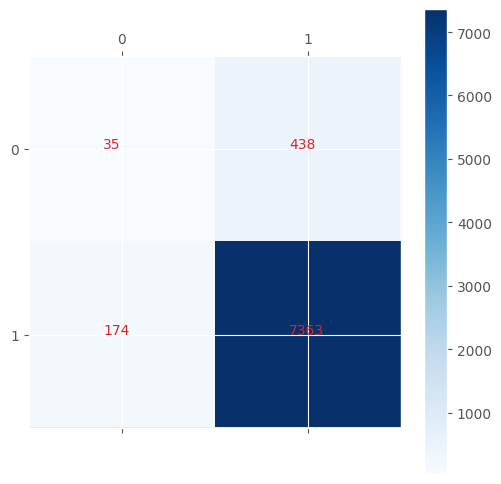

In [67]:
#Visualization for our XGBoost model confusion matrix 
plot_confusion_matrix(y_test1, prediction_xgb1)

In [68]:
def feature_importance(x, y, cluster):
    plt.figure(figsize = (16 , 9))
    sns.barplot(x = x.columns, y = y)
    plt.xlabel("Features")
    plt.xticks(rotation=90)
    plt.ylabel("% of Decisions")
    plt.title(f"Feature Importances for Cluster {cluster}")
    plt.tight_layout()
    #plt.savefig('Cluster1FeatureImportance.png')
    plt.show()

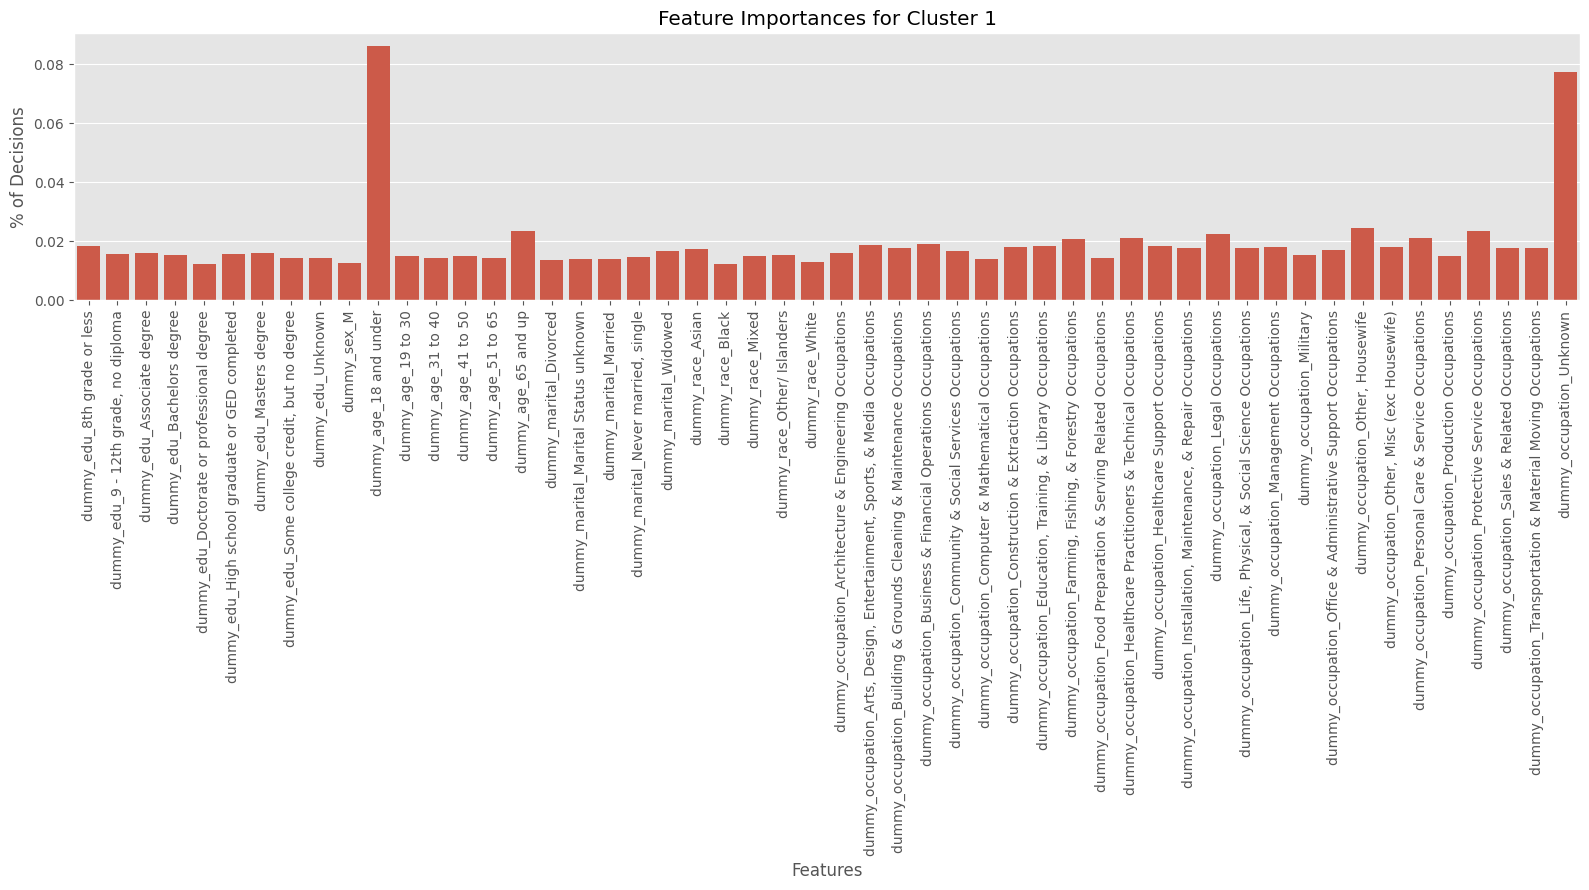

In [69]:
clus1_features = xgb1.feature_importances_

feature_importance(x_train1, clus1_features, 1)

In [ ]:
clus1_feature_importances_table = pd.DataFrame(data = {"Features": x_train1.columns, "Data": clus1_features})
clus1_feature_importances_table[clus1_feature_importances_table["Data"] > 0]

,Features,Data
0,dummy_edu_8th grade or less,0.018223
1,"dummy_edu_9 - 12th grade, no diploma",0.015753
2,dummy_edu_Associate degree,0.016120
3,dummy_edu_Bachelors degree,0.015161
4,dummy_edu_Doctorate or professional degree,0.012250
5,dummy_edu_High school graduate or GED completed,0.015804
6,dummy_edu_Masters degree,0.015847
7,"dummy_edu_Some college credit, but no degree",0.014206
8,dummy_edu_Unknown,0.014154
9,dummy_sex_M,0.012702


In [71]:
#https://stackoverflow.com/questions/47462690/how-to-get-top-5-values-from-pandas-dataframe
clus1_top_5 = clus1_feature_importances_table.sort_values(by='Data', ascending=False).head(5)
clus1_top_5

,Features,Data
10,dummy_age_18 and under,0.086117
51,dummy_occupation_Unknown,0.077252
44,"dummy_occupation_Other, Housewife",0.024465
48,dummy_occupation_Protective Service Occupations,0.023562
15,dummy_age_65 and up,0.023329


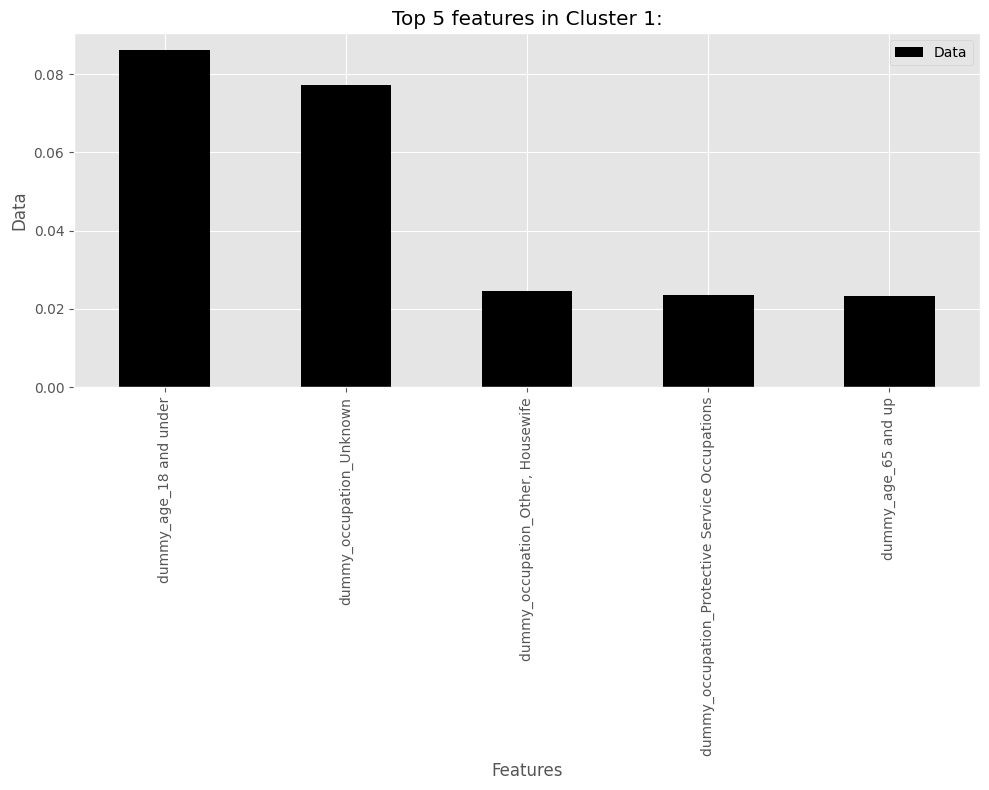

In [72]:
#Make a bar plot for the top 5 features in Cluster 1:
clus1_top_5.plot(kind='bar', x='Features', y='Data', color='black')
plt.title('Top 5 features in Cluster 1:')
plt.xlabel('Features')
plt.xticks(rotation=90)
plt.ylabel('Data')
plt.tight_layout()
plt.show()

# Cluster 2: XGBoost/ Oversample 20%/ Tuned

In [73]:
cluster_2 = cluster_2.drop('Clusters', axis=1)
cluster_2.head()

,Education,Sex,AgeCategory,Marital Status,Race,Occupation,Death
0,"9 - 12th grade, no diploma",M,18 and under,"Never married, single",White,"Other, Misc (exc Housewife)",Accidental Drug Poisoning
1,Unknown,F,51 to 65,Married,White,"Other, Misc (exc Housewife)",Other
2,Masters degree,M,41 to 50,Divorced,White,"Education, Training, & Library Occupations",Accidental Drug Poisoning
3,"Some college credit, but no degree",F,31 to 40,Married,Other/ Islanders,"Other, Misc (exc Housewife)",Accidental Drug Poisoning
4,"9 - 12th grade, no diploma",F,31 to 40,Married,Mixed,"Other, Misc (exc Housewife)",Accidental Drug Poisoning


In [74]:
cluster_2 = pd.get_dummies(cluster_2, columns=['Education', 'Sex', 'AgeCategory', 'Marital Status', 'Race', 'Occupation', 'Death'], prefix=['dummy_edu','dummy_sex','dummy_age', 'dummy_marital', 'dummy_race', 'dummy_occupation', 'dummy_death'])
cluster_2.head()

,dummy_edu_8th grade or less,"dummy_edu_9 - 12th grade, no diploma",dummy_edu_Associate degree,dummy_edu_Bachelors degree,dummy_edu_Doctorate or professional degree,dummy_edu_High school graduate or GED completed,dummy_edu_Masters degree,"dummy_edu_Some college credit, but no degree",dummy_edu_Unknown,dummy_sex_F,...,"dummy_occupation_Other, Housewife","dummy_occupation_Other, Misc (exc Housewife)",dummy_occupation_Personal Care & Service Occupations,dummy_occupation_Production Occupations,dummy_occupation_Protective Service Occupations,dummy_occupation_Sales & Related Occupations,dummy_occupation_Transportation & Material Moving Occupations,dummy_occupation_Unknown,dummy_death_Accidental Drug Poisoning,dummy_death_Other
0,0,1,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,1,0
1,0,0,0,0,0,0,0,0,1,1,...,0,1,0,0,0,0,0,0,0,1
2,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,1,0
3,0,0,0,0,0,0,0,1,0,1,...,0,1,0,0,0,0,0,0,1,0
4,0,1,0,0,0,0,0,0,0,1,...,0,1,0,0,0,0,0,0,1,0


In [75]:
# Death and Sex attribute has two values only so we can drop one of them since they are considered redundant. 
#We are predicting Accidental or not, so only 1 column is sufficient. 

cluster_2.drop('dummy_death_Other', axis=1, inplace=True)
cluster_2.rename(columns={'dummy_death_Accidental Drug Poisoning': 'Death'}, inplace=True)
cluster_2.drop('dummy_sex_F', axis=1, inplace=True)

#1 = Accidental, 0 = Other

In [76]:
clus2_train, clus2_test = train_test_split(cluster_2, test_size=0.25, random_state=34)
print(clus2_train.shape)
print(clus2_test.shape)

(9191, 53)
(3064, 53)


In [77]:
print(clus2_train["Death"].count())
print(clus2_train["Death"].value_counts(normalize = True))
clus2_train["Death"].value_counts()

9191
1    0.93548
0    0.06452
Name: Death, dtype: float64


1    8598
0     593
Name: Death, dtype: int64

In [78]:
num_samples_other_deaths_2 = determine_samples(len(clus2_train), 593, 0.2)
print("Other Deaths oversample samples to add in Cluster 2: ", num_samples_other_deaths_2)

Other Deaths oversample samples to add in Cluster 2:  1556


In [79]:
to_resample_2 = clus2_train.loc[clus2_train['Death'] == 0]

In [80]:
our_resample_2 = to_resample_2.sample(n = 1556 , replace = True)
clus2_train_rebal = pd.concat([clus2_train, our_resample_2])

In [81]:
clus2_train_rebal['Death'].value_counts()

1    8598
0    2149
Name: Death, dtype: int64

In [82]:
x_train2 = clus2_train_rebal.drop('Death', axis=1)
y_train2 = clus2_train_rebal['Death']

In [83]:
x_test2 = clus2_test.drop('Death', axis=1)
y_test2 = clus2_test['Death']

In [84]:
print(f'Our baseline model for Cluster 2 is {y_train2.value_counts(normalize = True)[1] * 100}% accurate')
print(f'Our baseline model for Cluster 2 based on the testing partition is {y_test2.value_counts(normalize = True)[1] * 100}% accurate')

Our baseline model for Cluster 2 is 80.00372196892155% accurate
Our baseline model for Cluster 2 based on the testing partition is 93.83159268929504% accurate


In [85]:
#Using CrossValidation for model selection: 
clus2_models_dict = {'RandomForest': RandomForestClassifier(n_estimators = 10, criterion='gini', random_state = 34), 
                     'NaiveBayes': MultinomialNB(alpha=1.0, fit_prior=True), 
                     'XGBoost': XGBClassifier(n_estimators=2, max_depth=2, learning_rate=1, objective='binary:logistic'),
                     'Decision Tree': DecisionTreeClassifier(criterion="entropy",max_leaf_nodes=5, random_state = 34)}

clus2_model_cv_score = {}

for name, model in clus2_models_dict.items():
    score2 = cross_val_score(model, x_train2, y_train2, cv=kfold)
    clus2_model_cv_score[name] = score2.mean()

print(f'Model Scores: {clus2_model_cv_score}')

Model Scores: {'RandomForest': 0.8263709670434368, 'NaiveBayes': 0.8007818630635312, 'XGBoost': 0.8001307868866657, 'Decision Tree': 0.8018979689056343}


In [72]:
#We are going to use XGBoost or DecisionTree as they have the highest accuracies (using stratified k fold cv)
clus2_params = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'gamma': [0, 0.1, 0.2],
    'min_child_weight': [1, 3, 5, 7],
    'scale_pos_weight': [3, 4, 5] #8598 / 2149 = 4(oversampled)
}

grid2 = GridSearchCV(XGBClassifier(), param_grid = clus2_params, cv = kfold, n_jobs = -1, verbose = 1)
grid2.fit(x_train2, y_train2)

print("Best Parameters found for Cluster 2: ", grid2.best_params_)
print("Best Accuracy through grid search for Cluster 2: %.3f"%grid2.best_score_)

Fitting 10 folds for each of 15552 candidates, totalling 155520 fits
Best Parameters found for Cluster 2:  {'colsample_bytree': 0.9, 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 9, 'min_child_weight': 1, 'n_estimators': 400, 'scale_pos_weight': 3, 'subsample': 0.9}
Best Accuracy through grid search for Cluster 2: 0.823


In [71]:
#We are going to use XGBoost or DecisionTree as they have the highest accuracies (using stratified k fold cv)
clus2_params = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.6, 0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9],
    'min_child_weight': [1, 3, 5, 7]
}

grid2 = GridSearchCV(XGBClassifier(), param_grid = clus2_params, cv = kfold, n_jobs = -1, verbose = 1)
grid2.fit(x_train2, y_train2)

print("Best Parameters found for Cluster 2: ", grid2.best_params_)
print("Best Accuracy through grid search for Cluster 2: %.3f"%grid2.best_score_)

Fitting 10 folds for each of 3840 candidates, totalling 38400 fits
Best Parameters found for Cluster 2:  {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 9, 'min_child_weight': 1, 'n_estimators': 500, 'subsample': 0.9}
Best Accuracy through grid search for Cluster 2: 0.826


In [86]:
#BEST SCORE:
xgb2 = XGBClassifier(colsample_bytree = 0.7, learning_rate = 0.1, max_depth = 9, min_child_weight = 1, 
                     n_estimators = 500, subsample = 0.9, random_state=34).fit(x_train2, y_train2)

xgb2_score = cross_val_score(xgb2, x_train2, y_train2, cv=kfold)

In [87]:
print(f"Our XGBoost with the best optimized parameters on the Testing set for Cluster 2 is: {xgb2.score(x_test2, y_test2) * 100}% accurate")
print(f"Our XGBoost Classification model with optimized parameters with k-fold cross validation on the training dataset for Cluster 2 is: {xgb2_score.mean() * 100}% accurate")

Our XGBoost with the best optimized parameters on the Testing set for Cluster 2 is: 90.79634464751958% accurate
Our XGBoost Classification model with optimized parameters with k-fold cross validation on the training dataset for Cluster 2 is: 82.26494305140531% accurate


In [88]:
prediction_xgb2 = xgb2.predict(x_test2)

print("Classification Report for Cluster 2:")
print(classification_report(y_test2, prediction_xgb2))
print("===========")
print("Confusion Matrix")
print(confusion_matrix(y_test2, prediction_xgb2))
print("============")
print("Accuracy Score: ", accuracy_score(prediction_xgb2, y_test2))
print("==============")

test2_predictions_proba = xgb2.predict_proba(x_test2)
log_2 = log_loss(y_test2, test2_predictions_proba)
print("Log Loss: {:.4}".format(log_2))
print("===============")

Classification Report for Cluster 2:
              precision    recall  f1-score   support

           0       0.09      0.05      0.07       189
           1       0.94      0.96      0.95      2875

    accuracy                           0.91      3064
   macro avg       0.51      0.51      0.51      3064
weighted avg       0.89      0.91      0.90      3064

Confusion Matrix
[[  10  179]
 [ 103 2772]]
Accuracy Score:  0.9079634464751958
Log Loss: 0.3307


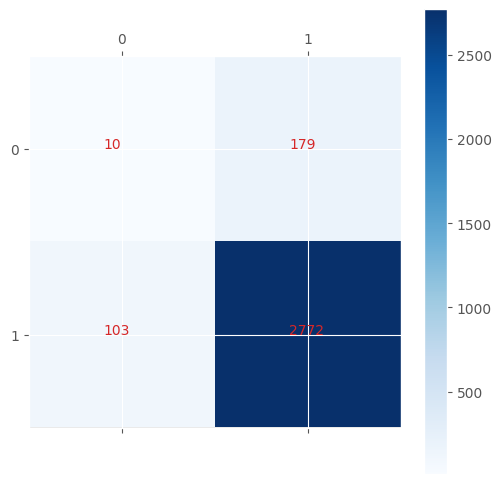

In [89]:
#Visualization for our XGBoost model confusion matrix 
plot_confusion_matrix(y_test2, prediction_xgb2)

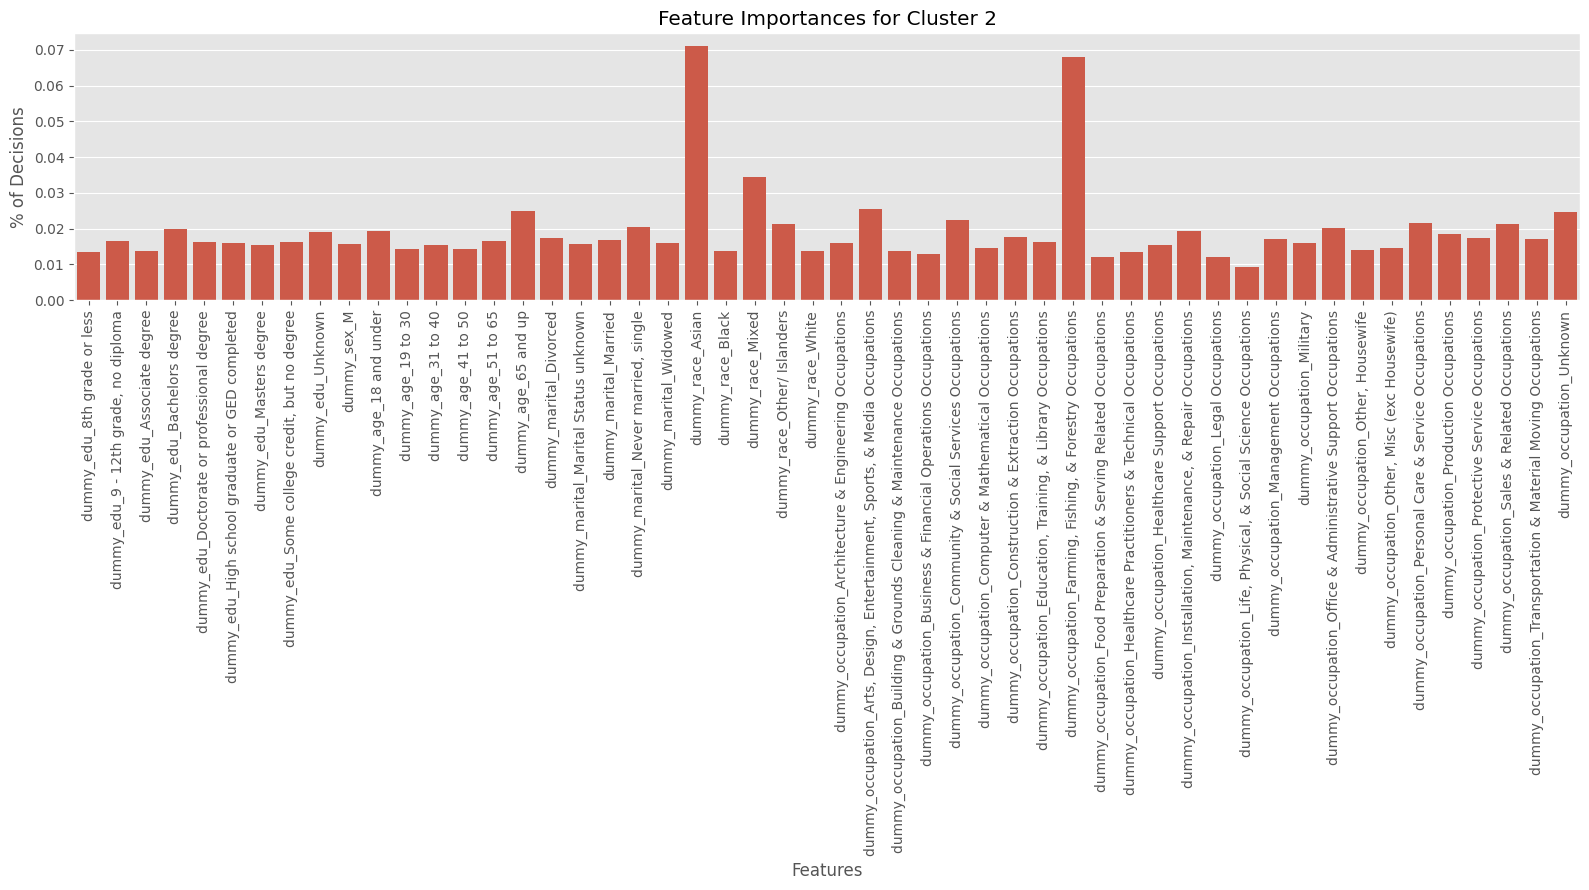

In [90]:
clus2_features = xgb2.feature_importances_
feature_importance(x_train2, clus2_features, 2)

In [ ]:
clus2_feature_importances_table = pd.DataFrame(data = {"Features": x_train2.columns, "Data": clus2_features})
clus2_feature_importances_table[clus2_feature_importances_table["Data"] > 0]

,Features,Data
0,dummy_edu_8th grade or less,0.013576
1,"dummy_edu_9 - 12th grade, no diploma",0.016555
2,dummy_edu_Associate degree,0.013813
3,dummy_edu_Bachelors degree,0.019919
4,dummy_edu_Doctorate or professional degree,0.016223
5,dummy_edu_High school graduate or GED completed,0.015959
6,dummy_edu_Masters degree,0.015512
7,"dummy_edu_Some college credit, but no degree",0.016341
8,dummy_edu_Unknown,0.019016
9,dummy_sex_M,0.015592


In [92]:
clus2_top_5 = clus2_feature_importances_table.sort_values(by='Data', ascending=False).head(5)
clus2_top_5

,Features,Data
21,dummy_race_Asian,0.071082
34,"dummy_occupation_Farming, Fishing, & Forestry ...",0.068106
23,dummy_race_Mixed,0.034480
27,"dummy_occupation_Arts, Design, Entertainment, ...",0.025494
15,dummy_age_65 and up,0.024958


# Cluster 3: XGBoost/ Oversample 20%/ Tuned

In [93]:
cluster_3 = cluster_3.drop('Clusters', axis=1)
cluster_3.head()

,Education,Sex,AgeCategory,Marital Status,Race,Occupation,Death
0,"Some college credit, but no degree",M,51 to 65,Divorced,Other/ Islanders,Management Occupations,Accidental Drug Poisoning
1,8th grade or less,M,65 and up,Divorced,White,Management Occupations,Accidental Drug Poisoning
2,High school graduate or GED completed,M,51 to 65,Divorced,White,Office & Administrative Support Occupations,Accidental Drug Poisoning
3,High school graduate or GED completed,F,51 to 65,Divorced,White,Food Preparation & Serving Related Occupations,Accidental Drug Poisoning
4,High school graduate or GED completed,M,65 and up,Married,Other/ Islanders,Construction & Extraction Occupations,Accidental Drug Poisoning


In [94]:
cluster_3 = pd.get_dummies(cluster_3, columns=['Education', 'Sex', 'AgeCategory', 'Marital Status', 'Race', 'Occupation', 'Death'], prefix=['dummy_edu','dummy_sex','dummy_age', 'dummy_marital', 'dummy_race', 'dummy_occupation', 'dummy_death'])
cluster_3.head()

,dummy_edu_8th grade or less,"dummy_edu_9 - 12th grade, no diploma",dummy_edu_Associate degree,dummy_edu_Bachelors degree,dummy_edu_Doctorate or professional degree,dummy_edu_High school graduate or GED completed,dummy_edu_Masters degree,"dummy_edu_Some college credit, but no degree",dummy_edu_Unknown,dummy_sex_F,...,"dummy_occupation_Other, Housewife","dummy_occupation_Other, Misc (exc Housewife)",dummy_occupation_Personal Care & Service Occupations,dummy_occupation_Production Occupations,dummy_occupation_Protective Service Occupations,dummy_occupation_Sales & Related Occupations,dummy_occupation_Transportation & Material Moving Occupations,dummy_occupation_Unknown,dummy_death_Accidental Drug Poisoning,dummy_death_Other
0,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
2,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
3,0,0,0,0,0,1,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0
4,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


In [95]:
# Death and Sex attribute has two values only so we can drop one of them since they are considered redundant. 
#We are predicting Accidental or not, so only 1 column is sufficient. 

cluster_3.drop('dummy_death_Other', axis=1, inplace=True)
cluster_3.rename(columns={'dummy_death_Accidental Drug Poisoning': 'Death'}, inplace=True)
cluster_3.drop('dummy_sex_F', axis=1, inplace=True)

#1 = Accidental, 0 = Other

In [96]:
clus3_train, clus3_test = train_test_split(cluster_3, test_size=0.25, random_state=34)
print(clus3_train.shape)
print(clus3_test.shape)

(9674, 53)
(3225, 53)


In [97]:
print(clus3_train["Death"].count())
print(clus3_train["Death"].value_counts(normalize = True))
clus3_train["Death"].value_counts()

9674
1    0.934257
0    0.065743
Name: Death, dtype: float64


1    9038
0     636
Name: Death, dtype: int64

In [98]:
num_samples_other_deaths_3 = determine_samples(len(clus3_train), 636, 0.2)
print("Other Deaths oversample samples to add in Cluster 3: ", num_samples_other_deaths_3)

Other Deaths oversample samples to add in Cluster 3:  1623


In [99]:
to_resample_3 = clus3_train.loc[clus3_train['Death'] == 0]

In [100]:
our_resample_3 = to_resample_3.sample(n = 1623 , replace = True)
clus3_train_rebal = pd.concat([clus3_train, our_resample_3])

In [101]:
clus3_train_rebal['Death'].value_counts()

1    9038
0    2259
Name: Death, dtype: int64

In [102]:
x_train3 = clus3_train_rebal.drop('Death', axis=1)
y_train3 = clus3_train_rebal['Death']

In [103]:
x_test3 = clus3_test.drop('Death', axis=1)
y_test3 = clus3_test['Death']

In [104]:
print(f'Our baseline model for Cluster 3 is {y_train3.value_counts(normalize = True)[1] * 100}% accurate')
print(f'Our baseline model for Cluster 3 based on the testing partition is {y_test3.value_counts(normalize = True)[1] * 100}% accurate')

Our baseline model for Cluster 3 is 80.00354076303444% accurate
Our baseline model for Cluster 3 based on the testing partition is 93.82945736434108% accurate


In [105]:
#Using CrossValidation for model selection: 
clus3_models_dict = {'RandomForest': RandomForestClassifier(n_estimators = 10, criterion='gini', random_state = 34), 
                     'NaiveBayes': MultinomialNB(alpha=1.0, fit_prior=True), 
                     'XGBoost': XGBClassifier(n_estimators=2, max_depth=2, learning_rate=1, objective='binary:logistic'),
                     'Decision Tree': DecisionTreeClassifier(criterion="entropy",max_leaf_nodes=5, random_state = 34)}

clus3_model_cv_score = {}

for name, model in clus3_models_dict.items():
    score3 = cross_val_score(model, x_train3, y_train3, cv=kfold)
    clus3_model_cv_score[name] = score3.mean()

print(f'Model Scores: {clus3_model_cv_score}')

Model Scores: {'RandomForest': 0.8155256825289825, 'NaiveBayes': 0.7993260540693072, 'XGBoost': 0.7981749845191531, 'Decision Tree': 0.8005652272745086}


In [86]:
#We are going to use XGBoost or DecisionTree as they have the highest accuracies (using stratified k fold cv)
clus3_params = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'gamma': [0, 0.1, 0.2],
    'min_child_weight': [3, 5, 7],
    'scale_pos_weight': [3, 4, 5]
}

grid3 = GridSearchCV(XGBClassifier(), param_grid = clus3_params, cv = kfold, n_jobs = -1, verbose = 1)
grid3.fit(x_train3, y_train3)

print("Best Parameters found for Cluster 3:", grid3.best_params_)
print("Best Accuracy through grid search for Cluster 3:%.3f"%grid3.best_score_)

Fitting 10 folds for each of 11664 candidates, totalling 116640 fits
Best Parameters found for Cluster 3: {'colsample_bytree': 0.9, 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 9, 'min_child_weight': 3, 'n_estimators': 400, 'scale_pos_weight': 3, 'subsample': 0.8}
Best Accuracy through grid search for Cluster 3:0.806


In [85]:
clus3_params = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.6, 0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9],
    'min_child_weight': [1, 3, 5, 7]
}

grid3 = GridSearchCV(XGBClassifier(), param_grid = clus3_params, cv = kfold, n_jobs = -1, verbose = 1)
grid3.fit(x_train3, y_train3)

print("Best Parameters found for Cluster 3:", grid3.best_params_)
print("Best Accuracy through grid search for Cluster 3:%.3f"%grid3.best_score_)

Fitting 10 folds for each of 3840 candidates, totalling 38400 fits
Best Parameters found for Cluster 3: {'colsample_bytree': 0.9, 'learning_rate': 0.1, 'max_depth': 9, 'min_child_weight': 1, 'n_estimators': 500, 'subsample': 0.8}
Best Accuracy through grid search for Cluster 3:0.817


In [106]:
#BEST SCORE:
xgb3 = XGBClassifier(colsample_bytree = 0.9, learning_rate = 0.1, max_depth = 9, min_child_weight = 1, 
                     n_estimators = 500, subsample = 0.8, random_state=34).fit(x_train3, y_train3) 

xgb3_score = cross_val_score(xgb3, x_train3, y_train3, cv=kfold)

In [107]:
print(f"Our XGBoost with the best optimized parameters on the Testing set for Cluster 3 is: {xgb3.score(x_test3, y_test3) * 100}% accurate")
print(f"Our XGBoost Classification model with optimized parameters with k-fold cross validation on the training dataset for Cluster 3 is: {xgb3_score.mean() * 100}% accurate")

Our XGBoost with the best optimized parameters on the Testing set for Cluster 3 is: 91.1937984496124% accurate
Our XGBoost Classification model with optimized parameters with k-fold cross validation on the training dataset for Cluster 3 is: 81.30476496547183% accurate


In [108]:
prediction_xgb3 = xgb3.predict(x_test3)

print("Classification Report for Cluster 3:")
print(classification_report(y_test3, prediction_xgb3))
print("===========")
print("Confusion Matrix")
print(confusion_matrix(y_test3, prediction_xgb3))
print("============")
print("Accuracy Score: ", accuracy_score(prediction_xgb3, y_test3))
print("==============")

test3_predictions_proba = xgb3.predict_proba(x_test3)
log_3 = log_loss(y_test3, test3_predictions_proba)
print("Log Loss: {:.4}".format(log_3))
print("===============")

Classification Report for Cluster 3:
              precision    recall  f1-score   support

           0       0.06      0.03      0.04       199
           1       0.94      0.97      0.95      3026

    accuracy                           0.91      3225
   macro avg       0.50      0.50      0.50      3225
weighted avg       0.88      0.91      0.90      3225

Confusion Matrix
[[   6  193]
 [  91 2935]]
Accuracy Score:  0.9119379844961241
Log Loss: 0.3338


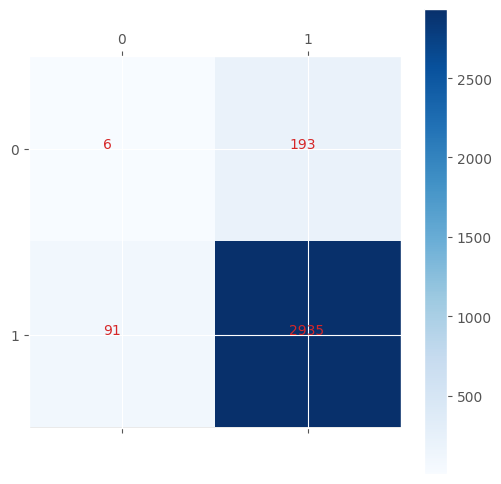

In [109]:
#Visualization for our XGBoost model confusion matrix 
plot_confusion_matrix(y_test3, prediction_xgb3)

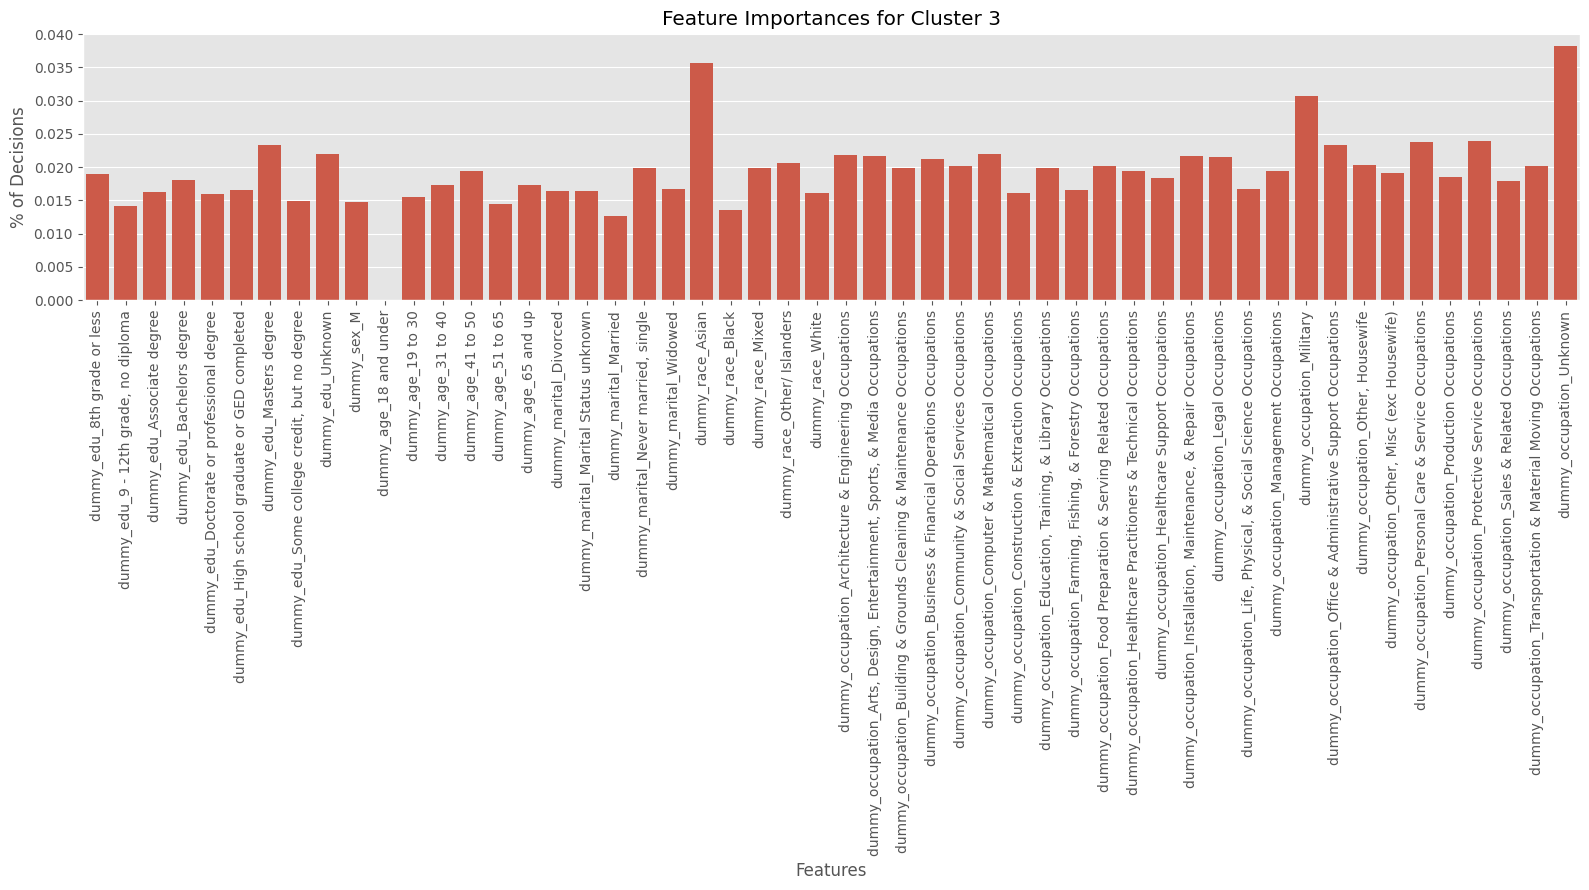

In [110]:
clus3_features = xgb3.feature_importances_

feature_importance(x_train3, clus3_features, 3)

In [ ]:
clus3_feature_importances_table = pd.DataFrame(data = {"Features": x_train3.columns, "Data": clus3_features})
clus3_feature_importances_table[clus3_feature_importances_table["Data"] > 0]

,Features,Data
0,dummy_edu_8th grade or less,0.018979
1,"dummy_edu_9 - 12th grade, no diploma",0.014124
2,dummy_edu_Associate degree,0.016342
3,dummy_edu_Bachelors degree,0.018008
4,dummy_edu_Doctorate or professional degree,0.016034
5,dummy_edu_High school graduate or GED completed,0.016498
6,dummy_edu_Masters degree,0.023353
7,"dummy_edu_Some college credit, but no degree",0.014949
8,dummy_edu_Unknown,0.021944
9,dummy_sex_M,0.014790


In [112]:
clus3_top_5 = clus3_feature_importances_table.sort_values(by='Data', ascending=False).head(5)
clus3_top_5

,Features,Data
51,dummy_occupation_Unknown,0.038206
21,dummy_race_Asian,0.035651
42,dummy_occupation_Military,0.030753
48,dummy_occupation_Protective Service Occupations,0.023883
46,dummy_occupation_Personal Care & Service Occup...,0.023788


# Cluster 4: XGBoost/ Oversample 20%/ Tuned

In [113]:
cluster_4 = cluster_4.drop('Clusters', axis=1)
cluster_4.head()

,Education,Sex,AgeCategory,Marital Status,Race,Occupation,Death
0,High school graduate or GED completed,M,19 to 30,"Never married, single",Other/ Islanders,"Farming, Fishing, & Forestry Occupations",Accidental Drug Poisoning
1,High school graduate or GED completed,M,19 to 30,"Never married, single",White,"Farming, Fishing, & Forestry Occupations",Accidental Drug Poisoning
2,Bachelors degree,M,19 to 30,"Never married, single",Black,Business & Financial Operations Occupations,Accidental Drug Poisoning
3,"Some college credit, but no degree",M,19 to 30,"Never married, single",White,Healthcare Practitioners & Technical Occupations,Accidental Drug Poisoning
4,"9 - 12th grade, no diploma",M,19 to 30,"Never married, single",Other/ Islanders,"Other, Misc (exc Housewife)",Accidental Drug Poisoning


In [114]:
cluster_4 = pd.get_dummies(cluster_4, columns=['Education', 'Sex', 'AgeCategory', 'Marital Status', 'Race', 'Occupation', 'Death'], prefix=['dummy_edu','dummy_sex','dummy_age', 'dummy_marital', 'dummy_race', 'dummy_occupation', 'dummy_death'])
cluster_4.head()

,dummy_edu_8th grade or less,"dummy_edu_9 - 12th grade, no diploma",dummy_edu_Associate degree,dummy_edu_Bachelors degree,dummy_edu_Doctorate or professional degree,dummy_edu_High school graduate or GED completed,dummy_edu_Masters degree,"dummy_edu_Some college credit, but no degree",dummy_edu_Unknown,dummy_sex_F,...,"dummy_occupation_Other, Housewife","dummy_occupation_Other, Misc (exc Housewife)",dummy_occupation_Personal Care & Service Occupations,dummy_occupation_Production Occupations,dummy_occupation_Protective Service Occupations,dummy_occupation_Sales & Related Occupations,dummy_occupation_Transportation & Material Moving Occupations,dummy_occupation_Unknown,dummy_death_Accidental Drug Poisoning,dummy_death_Other
0,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
1,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
2,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
3,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,1,0
4,0,1,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,1,0


In [115]:
# Death and Sex attribute has two values only so we can drop one of them since they are considered redundant. 
#We are predicting Accidental or not, so only 1 column is sufficient. 

cluster_4.drop('dummy_death_Other', axis=1, inplace=True)
cluster_4.rename(columns={'dummy_death_Accidental Drug Poisoning': 'Death'}, inplace=True)
cluster_4.drop('dummy_sex_F', axis=1, inplace=True)

#1 = Accidental, 0 = Other

In [116]:
clus4_train, clus4_test = train_test_split(cluster_4, test_size=0.25, random_state=34)
print(clus4_train.shape)
print(clus4_test.shape)

(11271, 52)
(3758, 52)


In [117]:
print(clus4_train["Death"].count())
print(clus4_train["Death"].value_counts(normalize = True))
clus4_train["Death"].value_counts()

11271
1    0.948097
0    0.051903
Name: Death, dtype: float64


1    10686
0      585
Name: Death, dtype: int64

In [118]:
num_samples_other_deaths_4 = determine_samples(len(clus4_train), 585, 0.2)
print("Other Deaths oversample samples to add in Cluster 4: ", num_samples_other_deaths_4)

Other Deaths oversample samples to add in Cluster 4:  2086


In [119]:
to_resample_4 = clus4_train.loc[clus4_train['Death'] == 0]

In [120]:
our_resample_4 = to_resample_4.sample(n = 2086 , replace = True)
clus4_train_rebal = pd.concat([clus4_train, our_resample_4])

In [121]:
clus4_train_rebal['Death'].value_counts()

1    10686
0     2671
Name: Death, dtype: int64

In [122]:
x_train4 = clus4_train_rebal.drop('Death', axis=1)
y_train4 = clus4_train_rebal['Death']

In [123]:
x_test4 = clus4_test.drop('Death', axis=1)
y_test4 = clus4_test['Death']

In [124]:
print(f'Our baseline model for Cluster 4 is {y_train4.value_counts(normalize = True)[1] * 100}% accurate')
print(f'Our baseline model for Cluster 4 based on the testing partition is {y_test4.value_counts(normalize = True)[1] * 100}% accurate')

Our baseline model for Cluster 4 is 80.00299468443512% accurate
Our baseline model for Cluster 4 based on the testing partition is 94.598190526876% accurate


In [125]:
#Using CrossValidation for model selection: 
clus4_models_dict = {'RandomForest': RandomForestClassifier(n_estimators = 10, criterion='gini', random_state = 34), 
                     'NaiveBayes': MultinomialNB(alpha=1.0, fit_prior=True), 
                     'XGBoost': XGBClassifier(n_estimators=2, max_depth=2, learning_rate=1, objective='binary:logistic'),
                     'Decision Tree': DecisionTreeClassifier(criterion="entropy",max_leaf_nodes=5, random_state = 34)}

clus4_model_cv_score = {}

for name, model in clus4_models_dict.items():
    score4 = cross_val_score(model, x_train4, y_train4, cv=kfold)
    clus4_model_cv_score[name] = score4.mean()

print(f'Model Scores: {clus4_model_cv_score}')

Model Scores: {'RandomForest': 0.8078173428424049, 'NaiveBayes': 0.7997318845455157, 'XGBoost': 0.8001061360425217, 'Decision Tree': 0.8001061360425217}


In [99]:
#We are going to use XGBoost or DecisionTree as they have the highest accuracies (using stratified k fold cv)
clus4_params = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.6, 0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9],
    'min_child_weight': [1, 3, 5, 7]
}

grid4 = GridSearchCV(XGBClassifier(), param_grid = clus4_params, cv = kfold, n_jobs = -1, verbose = 1)
grid4.fit(x_train4, y_train4)

print("Best Parameters found for Cluster 4: ", grid4.best_params_)
print("Best Accuracy through grid search for Cluster 4: %.3f"%grid4.best_score_)

Fitting 10 folds for each of 3840 candidates, totalling 38400 fits
Best Parameters found for Cluster 4:  {'colsample_bytree': 0.9, 'learning_rate': 0.1, 'max_depth': 7, 'min_child_weight': 1, 'n_estimators': 400, 'subsample': 0.8}
Best Accuracy through grid search for Cluster 4: 0.806


In [126]:
#BEST SCORE:
xgb4 = XGBClassifier(colsample_bytree = 0.9, learning_rate = 0.1, max_depth = 7, min_child_weight = 1,
                     n_estimators = 400, subsample = 0.8, random_state=34).fit(x_train4, y_train4)

xgb4_score = cross_val_score(xgb4, x_train4, y_train4, cv=kfold)

In [127]:
print(f"Our XGBoost with the best optimized parameters on the Testing set for Cluster 4 is: {xgb4.score(x_test4, y_test4) * 100}% accurate")
print(f"Our XGBoost Classification model with optimized parameters with k-fold cross validation on the training dataset for Cluster 4 is: {xgb4_score.mean() * 100}% accurate")

Our XGBoost with the best optimized parameters on the Testing set for Cluster 4 is: 92.97498669505056% accurate
Our XGBoost Classification model with optimized parameters with k-fold cross validation on the training dataset for Cluster 4 is: 80.86404157976183% accurate


In [128]:
prediction_xgb4 = xgb4.predict(x_test4)

print("Classification Report for Cluster 4:")
print(classification_report(y_test4, prediction_xgb4))
print("===========")
print("Confusion Matrix")
print(confusion_matrix(y_test4, prediction_xgb4))
print("============")
print("Accuracy Score: ", accuracy_score(prediction_xgb4, y_test4))
print("==============")

test4_predictions_proba = xgb4.predict_proba(x_test4)
log_4 = log_loss(y_test4, test4_predictions_proba)
print("Log Loss: {:.4}".format(log_4))
print("===============")

Classification Report for Cluster 4:
              precision    recall  f1-score   support

           0       0.11      0.04      0.06       203
           1       0.95      0.98      0.96      3555

    accuracy                           0.93      3758
   macro avg       0.53      0.51      0.51      3758
weighted avg       0.90      0.93      0.91      3758

Confusion Matrix
[[   9  194]
 [  70 3485]]
Accuracy Score:  0.9297498669505055
Log Loss: 0.2971


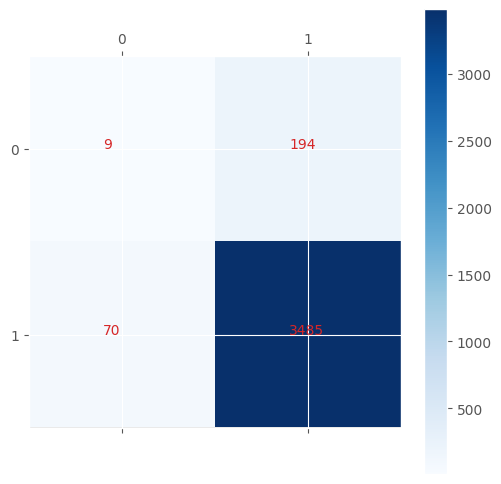

In [129]:
#Visualization for our XGBoost model confusion matrix 
plot_confusion_matrix(y_test4, prediction_xgb4)

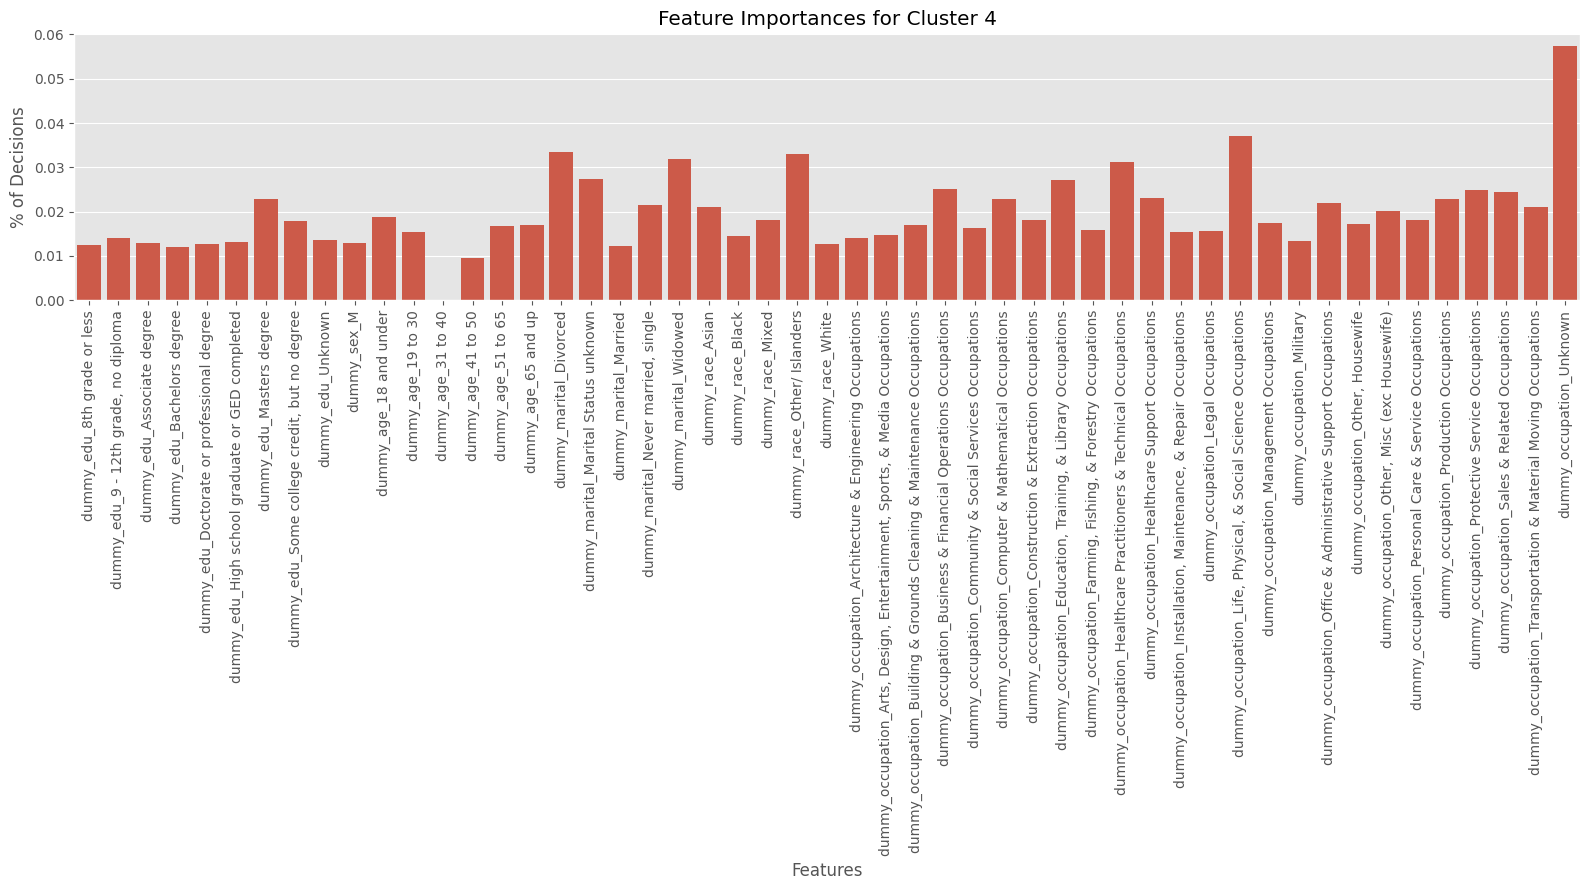

In [130]:
clus4_features = xgb4.feature_importances_

feature_importance(x_train4, clus4_features, 4)

In [ ]:
clus4_feature_importances_table = pd.DataFrame(data = {"Features": x_train4.columns, "Data": clus4_features})
clus4_feature_importances_table[clus4_feature_importances_table["Data"] > 0]

,Features,Data
0,dummy_edu_8th grade or less,0.012489
1,"dummy_edu_9 - 12th grade, no diploma",0.014052
2,dummy_edu_Associate degree,0.012959
3,dummy_edu_Bachelors degree,0.011988
4,dummy_edu_Doctorate or professional degree,0.012657
5,dummy_edu_High school graduate or GED completed,0.013118
6,dummy_edu_Masters degree,0.022850
7,"dummy_edu_Some college credit, but no degree",0.017854
8,dummy_edu_Unknown,0.013542
9,dummy_sex_M,0.013002


In [132]:
clus4_top_5 = clus4_feature_importances_table.sort_values(by='Data', ascending=False).head(5)
clus4_top_5

,Features,Data
50,dummy_occupation_Unknown,0.057394
39,"dummy_occupation_Life, Physical, & Social Scie...",0.037133
16,dummy_marital_Divorced,0.033380
24,dummy_race_Other/ Islanders,0.032904
20,dummy_marital_Widowed,0.031887


# Merging and getting graph of top 5 features:

In [194]:
# Adding a column to each top 5 features dataframe from each cluster 
#first to recognize what cluster the feature belongs to once we cut it.

clus1_top_5['Cluster'] = 'Cluster 1'
clus2_top_5['Cluster'] = 'Cluster 2'
clus3_top_5['Cluster'] = 'Cluster 3'
clus4_top_5['Cluster'] = 'Cluster 4'

In [195]:
clusters_top_5 = pd.concat([clus1_top_5, clus2_top_5, clus3_top_5, clus4_top_5], axis=0)
clusters_top_5.reset_index(drop=True, inplace=True)

clusters_top_5

,Features,Data,Cluster
0,dummy_age_18 and under,0.094055,Cluster 1
1,dummy_occupation_Unknown,0.068548,Cluster 1
2,dummy_age_65 and up,0.025091,Cluster 1
3,dummy_race_Asian,0.075175,Cluster 2
4,"dummy_occupation_Farming, Fishing, & Forestry ...",0.072581,Cluster 2
5,dummy_occupation_Unknown,0.026812,Cluster 2
6,dummy_occupation_Unknown,0.059263,Cluster 3
7,"dummy_occupation_Life, Physical, & Social Scie...",0.024674,Cluster 3
8,dummy_occupation_Office & Administrative Suppo...,0.023683,Cluster 3
9,dummy_occupation_Unknown,0.057664,Cluster 4


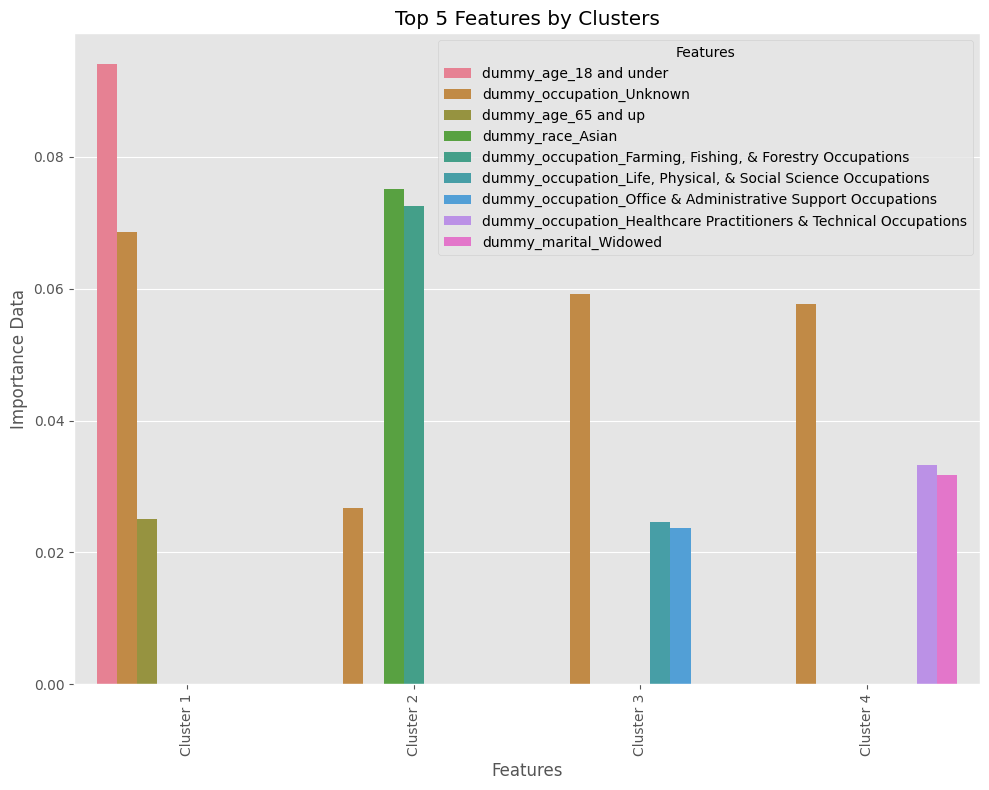

In [197]:
sns.barplot(x='Cluster', y='Data', hue='Features', data=clusters_top_5)

plt.xlabel("Features")
plt.xticks(rotation=90)
plt.ylabel("Importance Data")
plt.title("Top 5 Features by Clusters")
plt.legend(title='Features')
plt.tight_layout()
plt.show()

In [198]:
all_clusters_top_5 = clusters_top_5.sort_values(by='Data', ascending=False).head(5)
all_clusters_top_5

,Features,Data,Cluster
0,dummy_age_18 and under,0.094055,Cluster 1
3,dummy_race_Asian,0.075175,Cluster 2
4,"dummy_occupation_Farming, Fishing, & Forestry ...",0.072581,Cluster 2
1,dummy_occupation_Unknown,0.068548,Cluster 1
6,dummy_occupation_Unknown,0.059263,Cluster 3


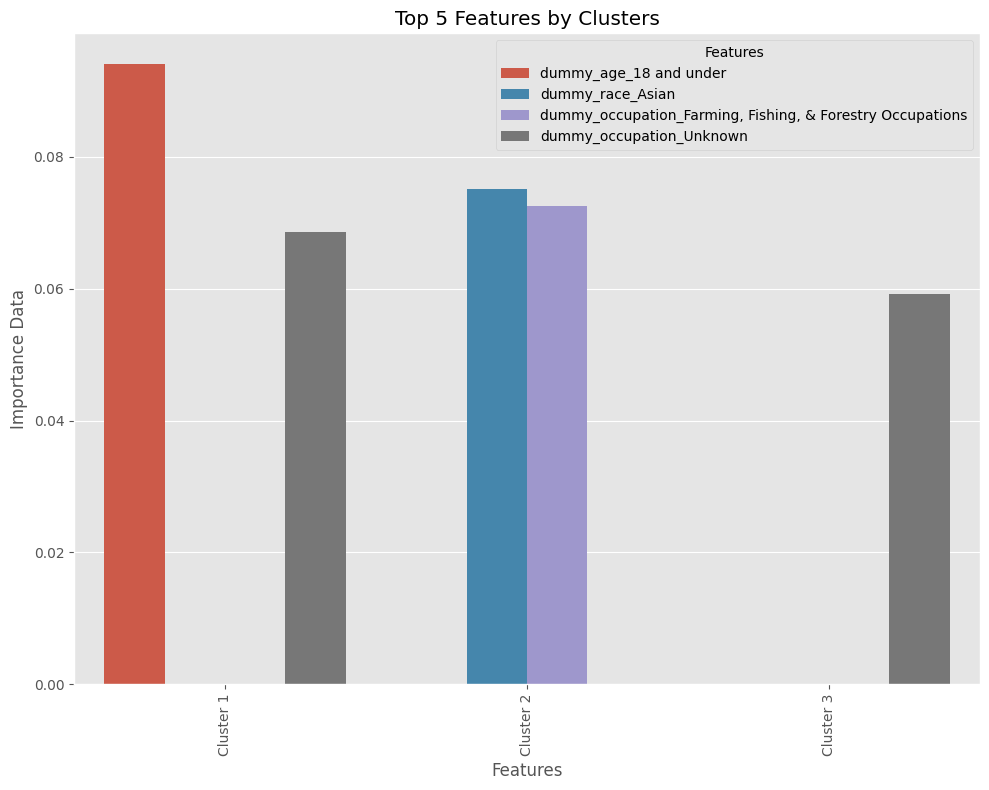

In [199]:
sns.barplot(x='Cluster', y='Data', hue='Features', data=all_clusters_top_5)

plt.xlabel("Features")
plt.xticks(rotation=90)
plt.ylabel("Importance Data")
plt.title("Top 5 Features by Clusters")
plt.legend(title='Features', loc='upper right')
plt.tight_layout()
plt.show()

# Cluster 1: XGBoost/ No oversample/ Tuned

In [53]:
cluster_1 = cluster_1.drop('Clusters', axis=1)
cluster_1.head()

,Education,Sex,AgeCategory,Marital Status,Race,Occupation,Death
0,"Some college credit, but no degree",M,31 to 40,"Never married, single",White,Management Occupations,Accidental Drug Poisoning
1,High school graduate or GED completed,M,31 to 40,"Never married, single",Other/ Islanders,Food Preparation & Serving Related Occupations,Accidental Drug Poisoning
2,Unknown,M,31 to 40,"Never married, single",Other/ Islanders,Construction & Extraction Occupations,Accidental Drug Poisoning
3,"9 - 12th grade, no diploma",F,31 to 40,Divorced,Other/ Islanders,"Other, Housewife",Accidental Drug Poisoning
4,High school graduate or GED completed,F,19 to 30,"Never married, single",White,Food Preparation & Serving Related Occupations,Accidental Drug Poisoning


In [54]:
cluster_1 = pd.get_dummies(cluster_1, columns=['Education', 'Sex', 'AgeCategory', 'Marital Status', 'Race', 'Occupation', 'Death'], prefix=['dummy_edu','dummy_sex','dummy_age', 'dummy_marital', 'dummy_race', 'dummy_occupation', 'dummy_death'])
cluster_1.head()

,dummy_edu_8th grade or less,"dummy_edu_9 - 12th grade, no diploma",dummy_edu_Associate degree,dummy_edu_Bachelors degree,dummy_edu_Doctorate or professional degree,dummy_edu_High school graduate or GED completed,dummy_edu_Masters degree,"dummy_edu_Some college credit, but no degree",dummy_edu_Unknown,dummy_sex_F,...,"dummy_occupation_Other, Housewife","dummy_occupation_Other, Misc (exc Housewife)",dummy_occupation_Personal Care & Service Occupations,dummy_occupation_Production Occupations,dummy_occupation_Protective Service Occupations,dummy_occupation_Sales & Related Occupations,dummy_occupation_Transportation & Material Moving Occupations,dummy_occupation_Unknown,dummy_death_Accidental Drug Poisoning,dummy_death_Other
0,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,1,0
1,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
2,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,1,0
3,0,1,0,0,0,0,0,0,0,1,...,1,0,0,0,0,0,0,0,1,0
4,0,0,0,0,0,1,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0


In [55]:
# Sex and Death attribute has two values only so we can drop one of them since they are considered redundant. 

cluster_1.drop('dummy_death_Other', axis=1, inplace=True)
cluster_1.rename(columns={'dummy_death_Accidental Drug Poisoning': 'Death'}, inplace=True)
cluster_1.drop('dummy_sex_F', axis=1, inplace=True)

#1 = Accidental, 0 = Other

In [56]:
clus1_train, clus1_test = train_test_split(cluster_1, test_size=0.25, random_state=34)
print(clus1_train.shape)
print(clus1_test.shape)

(24030, 53)
(8010, 53)


In [57]:
print(clus1_train["Death"].count())
print(clus1_train["Death"].value_counts(normalize = True))
clus1_train["Death"].value_counts()

24030
1    0.937703
0    0.062297
Name: Death, dtype: float64


1    22533
0     1497
Name: Death, dtype: int64

In [58]:
x_train1 = clus1_train.drop('Death', axis=1)
y_train1 = clus1_train['Death']

In [59]:
x_test1 = clus1_test.drop('Death', axis=1)
y_test1 = clus1_test['Death']

In [60]:
kfold = KFold(n_splits= 10, shuffle=True, random_state=34)

In [61]:
print(f'Our baseline model for Cluster 1 is {y_train1.value_counts(normalize = True)[0] * 100}% accurate')
print(f'Our baseline model for Cluster 1 based on the testing partition is {y_test1.value_counts(normalize = True)[0] * 100}% accurate')

Our baseline model for Cluster 1 is 6.229712858926343% accurate
Our baseline model for Cluster 1 based on the testing partition is 5.905118601747815% accurate


In [62]:
#Using CrossValidation for model selection: 
clus1_models_dict = {'RandomForest': RandomForestClassifier(n_estimators = 10, criterion='gini', random_state = 34), 
                     'NaiveBayes': MultinomialNB(alpha=1.0, fit_prior=True), 
                     'XGBoost': XGBClassifier(n_estimators=2, max_depth=2, learning_rate=1, objective='binary:logistic'),
                     'Decision Tree': DecisionTreeClassifier(criterion="entropy",max_leaf_nodes=5, random_state = 34)}

clus1_model_cv_score = {}

for name, model in clus1_models_dict.items():
    score1 = cross_val_score(model, x_train1, y_train1, cv=kfold)
    clus1_model_cv_score[name] = score1.mean()

print(f'Model Scores: {clus1_model_cv_score}')

Model Scores: {'RandomForest': 0.9339991677070328, 'NaiveBayes': 0.9378277153558052, 'XGBoost': 0.9386183936745734, 'Decision Tree': 0.9384519350811485}


In [62]:
#We are going to use XGBoost or DecisionTree as they have the highest accuracies (using stratified k fold cv)
clus1_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'gamma': [0, 0.1, 0.2],
    'min_child_weight': [3, 5, 7],
    'scale_pos_weight': [10, 15, 20]
}

grid1 = GridSearchCV(XGBClassifier(), param_grid = clus1_params, cv = kfold, n_jobs = -1, verbose = 1)
grid1.fit(x_train1, y_train1)

print("Best Parameters found for Cluster 1: ", grid1.best_params_)
print("Best Accuracy through grid search for Cluster 1: %.3f"%grid1.best_score_)

Fitting 10 folds for each of 6561 candidates, totalling 65610 fits
Best Parameters found for Cluster 1:  {'colsample_bytree': 0.9, 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 7, 'min_child_weight': 3, 'n_estimators': 300, 'scale_pos_weight': 20, 'subsample': 0.8}
Best Accuracy through grid search for Cluster 1: 0.938


In [63]:
#BEST SCORE: 0.27/ 0.82/ 78.83% = FOUND IN GRIDSEARCH RUN 2
xgb1 = XGBClassifier(colsample_bytree = 0.9, gamma = 0, learning_rate = 0.1, max_depth = 7, 
                     min_child_weight = 3, n_estimators = 300, scale_pos_weight = 20, subsample = 0.8, random_state=34).fit(x_train1, y_train1)

xgb1_score = cross_val_score(xgb1, x_train1, y_train1, cv=kfold)

In [64]:
print(f"Our XGBoost with the best optimized parameters on the Testing set for Cluster 1 is: {xgb1.score(x_test1, y_test1) * 100}% accurate")
print(f"Our XGBoost Classification model with optimized parameters with k-fold cross validation on the training dataset for Cluster 1 is: {xgb1_score.mean() * 100}% accurate")

Our XGBoost with the best optimized parameters on the Testing set for Cluster 1 is: 94.08239700374533% accurate
Our XGBoost Classification model with optimized parameters with k-fold cross validation on the training dataset for Cluster 1 is: 93.76612567623802% accurate


In [65]:
prediction_xgb1 = xgb1.predict(x_test1)

print("Classification Report for Cluster 1:")
print(classification_report(y_test1, prediction_xgb1))
print("===========")
print("Confusion Matrix")
print(confusion_matrix(y_test1, prediction_xgb1))
print("============")
print("Accuracy Score: ", accuracy_score(prediction_xgb1, y_test1))
print("==============")

test1_predictions_proba = xgb1.predict_proba(x_test1)
log_1 = log_loss(y_test1, test1_predictions_proba)
print("Log Loss: {:.4}".format(log_1))
print("===============")

Classification Report for Cluster 1:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       473
           1       0.94      1.00      0.97      7537

    accuracy                           0.94      8010
   macro avg       0.47      0.50      0.48      8010
weighted avg       0.89      0.94      0.91      8010

Confusion Matrix
[[   0  473]
 [   1 7536]]
Accuracy Score:  0.9408239700374532
Log Loss: 0.3395


In [66]:
def plot_confusion_matrix(Y_test, Y_preds):
    conf_mat = confusion_matrix(Y_test, Y_preds)
    fig = plt.figure(figsize=(6,6))
    plt.matshow(conf_mat, cmap=plt.cm.Blues, fignum=1)
    plt.yticks(range(2), range(2))
    plt.xticks(range(2), range(2))
    plt.colorbar();
    for i in range(2):
        for j in range(2):
            plt.text(i-0.1,j, str(conf_mat[j, i]), color='tab:red')
    #plt.savefig('Cluster1ConfusionMatrix.png')

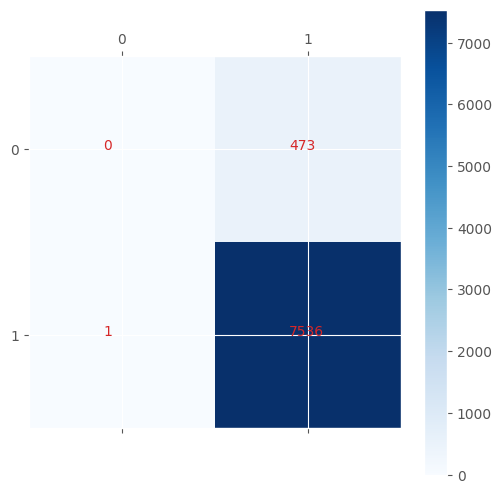

In [67]:
#Visualization for our XGBoost model confusion matrix 
plot_confusion_matrix(y_test1, prediction_xgb1)

In [68]:
def feature_importance(x, y, cluster):
    plt.figure(figsize = (16 , 9))
    sns.barplot(x = x.columns, y = y)
    plt.xlabel("Features")
    plt.xticks(rotation=90)
    plt.ylabel("% of Decisions")
    plt.title(f"Feature Importances for Cluster {cluster}")
    plt.tight_layout()
    #plt.savefig('Cluster1FeatureImportance.png')
    plt.show()

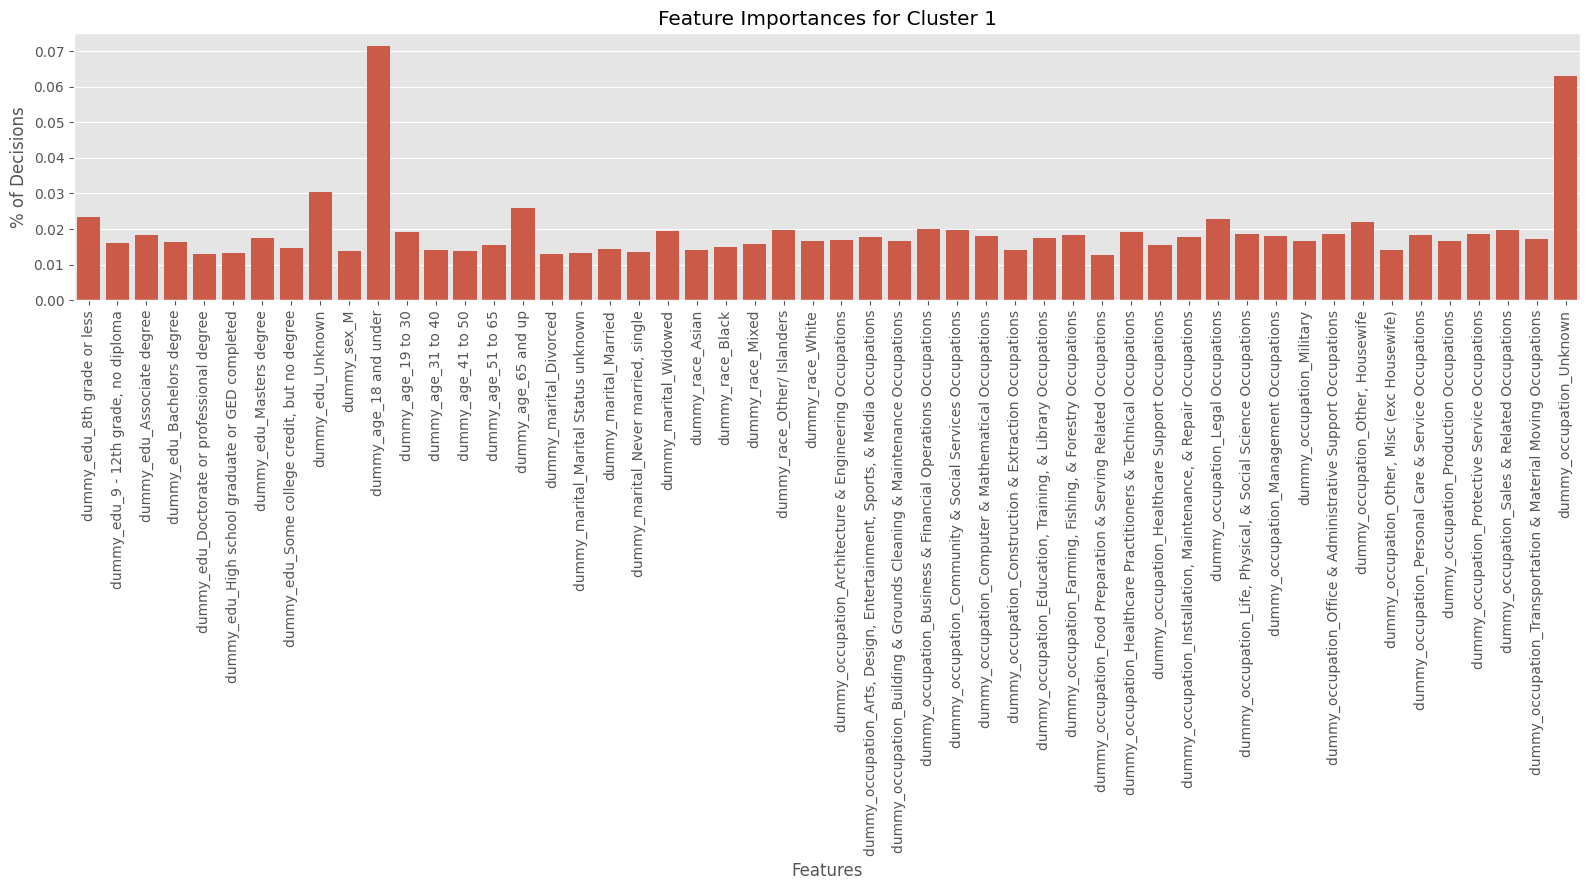

In [69]:
clus1_features = xgb1.feature_importances_

feature_importance(x_train1, clus1_features, 1)

In [ ]:
clus1_feature_importances_table = pd.DataFrame(data = {"Features": x_train1.columns, "Data": clus1_features})
clus1_feature_importances_table[clus1_feature_importances_table["Data"] > 0]

,Features,Data
0,dummy_edu_8th grade or less,0.023275
1,"dummy_edu_9 - 12th grade, no diploma",0.015993
2,dummy_edu_Associate degree,0.018198
3,dummy_edu_Bachelors degree,0.016385
4,dummy_edu_Doctorate or professional degree,0.012978
5,dummy_edu_High school graduate or GED completed,0.013246
6,dummy_edu_Masters degree,0.017508
7,"dummy_edu_Some college credit, but no degree",0.014650
8,dummy_edu_Unknown,0.030340
9,dummy_sex_M,0.013892


# Cluster 2: XGBoost/ No oversample/ Tuned

In [42]:
cluster_2 = cluster_2.drop('Clusters', axis=1)
cluster_2.head()

,Education,Sex,AgeCategory,Marital Status,Race,Occupation,Death
0,"9 - 12th grade, no diploma",M,18 and under,"Never married, single",White,"Other, Misc (exc Housewife)",Accidental Drug Poisoning
1,Unknown,F,51 to 65,Married,White,"Other, Misc (exc Housewife)",Other
2,Masters degree,M,41 to 50,Divorced,White,"Education, Training, & Library Occupations",Accidental Drug Poisoning
3,"Some college credit, but no degree",F,31 to 40,Married,Other/ Islanders,"Other, Misc (exc Housewife)",Accidental Drug Poisoning
4,"9 - 12th grade, no diploma",F,31 to 40,Married,Mixed,"Other, Misc (exc Housewife)",Accidental Drug Poisoning


In [43]:
cluster_2 = pd.get_dummies(cluster_2, columns=['Education', 'Sex', 'AgeCategory', 'Marital Status', 'Race', 'Occupation', 'Death'], prefix=['dummy_edu','dummy_sex','dummy_age', 'dummy_marital', 'dummy_race', 'dummy_occupation', 'dummy_death'])
cluster_2.head()

,dummy_edu_8th grade or less,"dummy_edu_9 - 12th grade, no diploma",dummy_edu_Associate degree,dummy_edu_Bachelors degree,dummy_edu_Doctorate or professional degree,dummy_edu_High school graduate or GED completed,dummy_edu_Masters degree,"dummy_edu_Some college credit, but no degree",dummy_edu_Unknown,dummy_sex_F,...,"dummy_occupation_Other, Housewife","dummy_occupation_Other, Misc (exc Housewife)",dummy_occupation_Personal Care & Service Occupations,dummy_occupation_Production Occupations,dummy_occupation_Protective Service Occupations,dummy_occupation_Sales & Related Occupations,dummy_occupation_Transportation & Material Moving Occupations,dummy_occupation_Unknown,dummy_death_Accidental Drug Poisoning,dummy_death_Other
0,0,1,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,1,0
1,0,0,0,0,0,0,0,0,1,1,...,0,1,0,0,0,0,0,0,0,1
2,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,1,0
3,0,0,0,0,0,0,0,1,0,1,...,0,1,0,0,0,0,0,0,1,0
4,0,1,0,0,0,0,0,0,0,1,...,0,1,0,0,0,0,0,0,1,0


In [44]:
# Death and Sex attribute has two values only so we can drop one of them since they are considered redundant. 
#We are predicting Accidental or not, so only 1 column is sufficient. 

cluster_2.drop('dummy_death_Other', axis=1, inplace=True)
cluster_2.rename(columns={'dummy_death_Accidental Drug Poisoning': 'Death'}, inplace=True)
cluster_2.drop('dummy_sex_F', axis=1, inplace=True)

#1 = Accidental, 0 = Other

In [45]:
#x2 = cluster_2.drop('Death', axis=1)
#y2 = cluster_2['Death']

In [46]:
clus2_train, clus2_test = train_test_split(cluster_2, test_size=0.25, random_state=34)
print(clus2_train.shape)
print(clus2_test.shape)

(9191, 53)
(3064, 53)


In [47]:
#x_train2, x_test2, y_train2, y_test2 = train_test_split(x2, y2, test_size=0.25, random_state=34, stratify=y2)

In [48]:
print(clus2_train["Death"].count())
print(clus2_train["Death"].value_counts(normalize = True))
clus2_train["Death"].value_counts()

9191
1    0.93548
0    0.06452
Name: Death, dtype: float64


1    8598
0     593
Name: Death, dtype: int64

In [49]:
x_train2 = clus2_train.drop('Death', axis=1)
y_train2 = clus2_train['Death']

In [50]:
x_test2 = clus2_test.drop('Death', axis=1)
y_test2 = clus2_test['Death']

In [51]:
print(f'Our baseline model for Cluster 2 is {y_train2.value_counts(normalize = True)[0] * 100}% accurate')
print(f'Our baseline model for Cluster 2 based on the testing partition is {y_test2.value_counts(normalize = True)[0] * 100}% accurate')

Our baseline model for Cluster 2 is 6.451963877706452% accurate
Our baseline model for Cluster 2 based on the testing partition is 6.1684073107049615% accurate


In [71]:
#Using CrossValidation for model selection: 
clus2_models_dict = {'RandomForest': RandomForestClassifier(n_estimators = 10, criterion='gini', random_state = 34), 
                     'NaiveBayes': MultinomialNB(alpha=1.0, fit_prior=True), 
                     'XGBoost': XGBClassifier(n_estimators=2, max_depth=2, learning_rate=1, objective='binary:logistic'),
                     'Decision Tree': DecisionTreeClassifier(criterion="entropy",max_leaf_nodes=5, random_state = 34)}

clus2_model_cv_score = {}

for name, model in clus2_models_dict.items():
    score2 = cross_val_score(model, x_train2, y_train2, cv=kfold)
    clus2_model_cv_score[name] = score2.mean()

print(f'Model Scores: {clus2_model_cv_score}')

Model Scores: {'RandomForest': 0.928080971755689, 'NaiveBayes': 0.9354794909400577, 'XGBoost': 0.9355883048682404, 'Decision Tree': 0.9354794909400577}


In [72]:
#We are going to use XGBoost or DecisionTree as they have the highest accuracies (using stratified k fold cv)
clus2_params = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'gamma': [0, 0.1, 0.2],
    'min_child_weight': [3, 5, 7],
    'scale_pos_weight': [10, 15, 20] 
}

grid2 = GridSearchCV(XGBClassifier(), param_grid = clus2_params, cv = kfold, n_jobs = -1, verbose = 1)
grid2.fit(x_train2, y_train2)

print("Best Parameters found for Cluster 2: ", grid2.best_params_)
print("Best Accuracy through grid search for Cluster 2: %.3f"%grid2.best_score_)

Fitting 10 folds for each of 8748 candidates, totalling 87480 fits
Best Parameters found for Cluster 2:  {'colsample_bytree': 0.7, 'gamma': 0, 'learning_rate': 0.01, 'max_depth': 3, 'min_child_weight': 3, 'n_estimators': 100, 'scale_pos_weight': 10, 'subsample': 0.7}
Best Accuracy through grid search for Cluster 2: 0.935


In [81]:
#BEST SCORE:
xgb2 = XGBClassifier(colsample_bytree = 0.7, gamma = 0, learning_rate=0.01, max_depth = 3, 
                     min_child_weight = 3, n_estimators = 100, scale_pos_weight = 10, subsample = 0.7, random_state=34).fit(x_train2, y_train2)

xgb2_score = cross_val_score(xgb2, x_train2, y_train2, cv=kfold)

In [82]:
print(f"Our XGBoost with the best optimized parameters on the Testing set for Cluster 2 is: {xgb2.score(x_test2, y_test2) * 100}% accurate")
print(f"Our XGBoost Classification model with optimized parameters with k-fold cross validation on the training dataset for Cluster 2 is: {xgb2_score.mean() * 100}% accurate")

Our XGBoost with the best optimized parameters on the Testing set for Cluster 2 is: 93.83159268929504% accurate
Our XGBoost Classification model with optimized parameters with k-fold cross validation on the training dataset for Cluster 2 is: 93.54794909400577% accurate


In [83]:
prediction_xgb2 = xgb2.predict(x_test2)

print("Classification Report for Cluster 2:")
print(classification_report(y_test2, prediction_xgb2))
print("===========")
print("Confusion Matrix")
print(confusion_matrix(y_test2, prediction_xgb2))
print("============")
print("Accuracy Score: ", accuracy_score(prediction_xgb2, y_test2))
print("==============")

test2_predictions_proba = xgb2.predict_proba(x_test2)
log_2 = log_loss(y_test2, test2_predictions_proba)
print("Log Loss: {:.4}".format(log_2))
print("===============")

Classification Report for Cluster 2:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       189
           1       0.94      1.00      0.97      2875

    accuracy                           0.94      3064
   macro avg       0.47      0.50      0.48      3064
weighted avg       0.88      0.94      0.91      3064

Confusion Matrix
[[   0  189]
 [   0 2875]]
Accuracy Score:  0.9383159268929504
Log Loss: 0.2313


/home/aryan/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/aryan/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/aryan/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


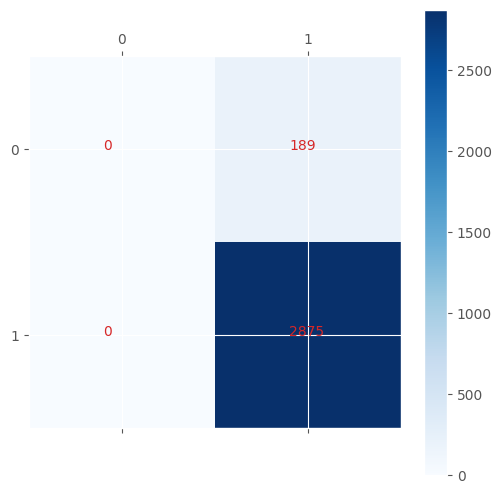

In [75]:
#Visualization for our XGBoost model confusion matrix 
plot_confusion_matrix(y_test2, prediction_xgb2)

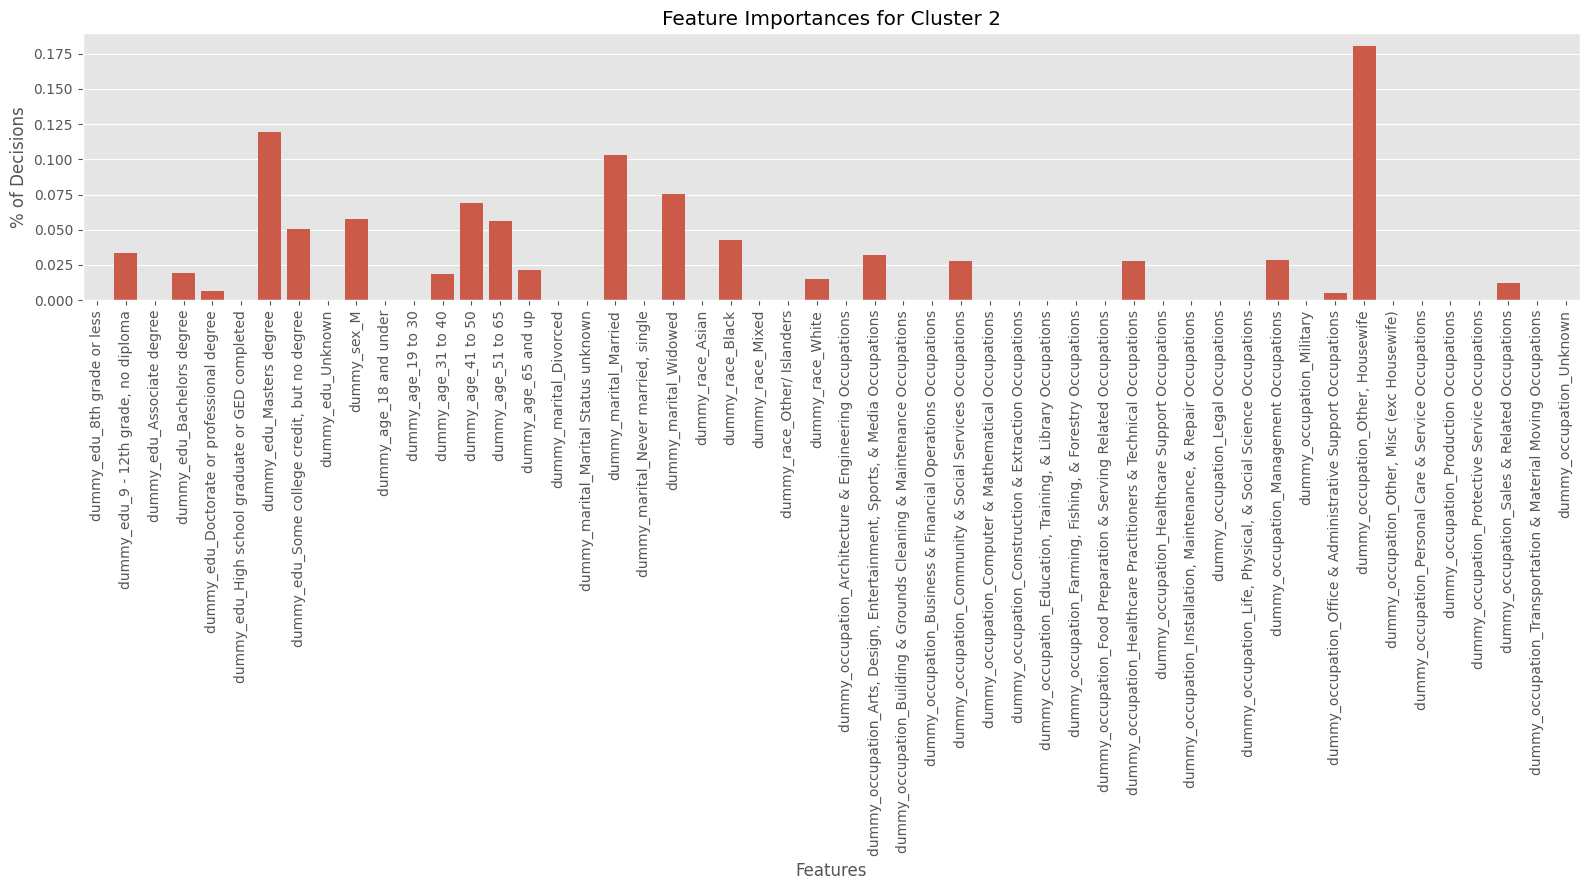

In [76]:
clus2_features = xgb2.feature_importances_
feature_importance(x_train2, clus2_features, 2)

In [ ]:
clus2_feature_importances_table = pd.DataFrame(data = {"Features": x_train2.columns, "Data": clus2_features})
clus2_feature_importances_table[clus2_feature_importances_table["Data"] > 0]

,Features,Data
1,"dummy_edu_9 - 12th grade, no diploma",0.033269
3,dummy_edu_Bachelors degree,0.018968
4,dummy_edu_Doctorate or professional degree,0.006771
6,dummy_edu_Masters degree,0.119333
7,"dummy_edu_Some college credit, but no degree",0.050213
9,dummy_sex_M,0.057750
12,dummy_age_31 to 40,0.018277
13,dummy_age_41 to 50,0.068700
14,dummy_age_51 to 65,0.056280
15,dummy_age_65 and up,0.021514


# Cluster 3: XGBoost/ No oversample/ Tuned

In [73]:
cluster_3 = cluster_3.drop('Clusters', axis=1)
cluster_3.head()

,Education,Sex,AgeCategory,Marital Status,Race,Occupation,Death
0,"Some college credit, but no degree",M,51 to 65,Divorced,Other/ Islanders,Management Occupations,Accidental Drug Poisoning
1,8th grade or less,M,65 and up,Divorced,White,Management Occupations,Accidental Drug Poisoning
2,High school graduate or GED completed,M,51 to 65,Divorced,White,Office & Administrative Support Occupations,Accidental Drug Poisoning
3,High school graduate or GED completed,F,51 to 65,Divorced,White,Food Preparation & Serving Related Occupations,Accidental Drug Poisoning
4,High school graduate or GED completed,M,65 and up,Married,Other/ Islanders,Construction & Extraction Occupations,Accidental Drug Poisoning


In [74]:
cluster_3 = pd.get_dummies(cluster_3, columns=['Education', 'Sex', 'AgeCategory', 'Marital Status', 'Race', 'Occupation', 'Death'], prefix=['dummy_edu','dummy_sex','dummy_age', 'dummy_marital', 'dummy_race', 'dummy_occupation', 'dummy_death'])
cluster_3.head()

,dummy_edu_8th grade or less,"dummy_edu_9 - 12th grade, no diploma",dummy_edu_Associate degree,dummy_edu_Bachelors degree,dummy_edu_Doctorate or professional degree,dummy_edu_High school graduate or GED completed,dummy_edu_Masters degree,"dummy_edu_Some college credit, but no degree",dummy_edu_Unknown,dummy_sex_F,...,"dummy_occupation_Other, Housewife","dummy_occupation_Other, Misc (exc Housewife)",dummy_occupation_Personal Care & Service Occupations,dummy_occupation_Production Occupations,dummy_occupation_Protective Service Occupations,dummy_occupation_Sales & Related Occupations,dummy_occupation_Transportation & Material Moving Occupations,dummy_occupation_Unknown,dummy_death_Accidental Drug Poisoning,dummy_death_Other
0,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
2,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
3,0,0,0,0,0,1,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0
4,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


In [75]:
# Death and Sex attribute has two values only so we can drop one of them since they are considered redundant. 
#We are predicting Accidental or not, so only 1 column is sufficient. 

cluster_3.drop('dummy_death_Other', axis=1, inplace=True)
cluster_3.rename(columns={'dummy_death_Accidental Drug Poisoning': 'Death'}, inplace=True)
cluster_3.drop('dummy_sex_F', axis=1, inplace=True)

#1 = Accidental, 0 = Other

In [76]:
clus3_train, clus3_test = train_test_split(cluster_3, test_size=0.25, random_state=34)
print(clus3_train.shape)
print(clus3_test.shape)

(9674, 53)
(3225, 53)


In [77]:
print(clus3_train["Death"].count())
print(clus3_train["Death"].value_counts(normalize = True))
clus3_train["Death"].value_counts()

9674
1    0.934257
0    0.065743
Name: Death, dtype: float64


1    9038
0     636
Name: Death, dtype: int64

In [78]:
x_train3 = clus3_train.drop('Death', axis=1)
y_train3 = clus3_train['Death']

In [79]:
x_test3 = clus3_test.drop('Death', axis=1)
y_test3 = clus3_test['Death']

In [80]:
print(f'Our baseline model for Cluster 3 is {y_train3.value_counts(normalize = True)[0] * 100}% accurate')
print(f'Our baseline model for Cluster 3 based on the testing partition is {y_test3.value_counts(normalize = True)[0] * 100}% accurate')

Our baseline model for Cluster 3 is 6.57432292743436% accurate
Our baseline model for Cluster 3 based on the testing partition is 6.170542635658915% accurate


In [81]:
#Using CrossValidation for model selection: 
clus3_models_dict = {'RandomForest': RandomForestClassifier(n_estimators = 10, criterion='gini', random_state = 34), 
                     'NaiveBayes': MultinomialNB(alpha=1.0, fit_prior=True), 
                     'XGBoost': XGBClassifier(n_estimators=2, max_depth=2, learning_rate=1, objective='binary:logistic'),
                     'Decision Tree': DecisionTreeClassifier(criterion="entropy",max_leaf_nodes=5, random_state = 34)}

clus3_model_cv_score = {}

for name, model in clus3_models_dict.items():
    score3 = cross_val_score(model, x_train3, y_train3, cv=kfold)
    clus3_model_cv_score[name] = score3.mean()

print(f'Model Scores: {clus3_model_cv_score}')

Model Scores: {'RandomForest': 0.928158144384524, 'NaiveBayes': 0.9339466869503534, 'XGBoost': 0.9342568179681559, 'Decision Tree': 0.9342568179681559}


In [82]:
#We are going to use XGBoost or DecisionTree as they have the highest accuracies (using stratified k fold cv)
clus3_params = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'gamma': [0, 0.1, 0.2],
    'min_child_weight': [3, 5, 7],
    'scale_pos_weight': [10, 15, 20]
}

grid3 = GridSearchCV(XGBClassifier(), param_grid = clus3_params, cv = kfold, n_jobs = -1, verbose = 1)
grid3.fit(x_train3, y_train3)

print("Best Parameters found for Cluster 3:", grid3.best_params_)
print("Best Accuracy through grid search for Cluster 3:%.3f"%grid3.best_score_)

Fitting 10 folds for each of 8748 candidates, totalling 87480 fits
Best Parameters found for Cluster 3: {'colsample_bytree': 0.7, 'gamma': 0, 'learning_rate': 0.01, 'max_depth': 3, 'min_child_weight': 3, 'n_estimators': 100, 'scale_pos_weight': 10, 'subsample': 0.7}
Best Accuracy through grid search for Cluster 3:0.934


In [148]:
#BEST SCORE:
xgb3 = XGBClassifier(colsample_bytree = 0.7, gamma = 0, learning_rate = 0.01, max_depth = 3,
                    min_child_weight = 3, n_estimators = 100, scale_pos_weight = 0.7, subsample = 0.7, random_state = 34).fit(x_train3, y_train3)

xgb3_score = cross_val_score(xgb3, x_train3, y_train3, cv=kfold)

In [149]:
print(f"Our XGBoost with the best optimized parameters on the Testing set for Cluster 3 is: {xgb3.score(x_test3, y_test3) * 100}% accurate")
print(f"Our XGBoost Classification model with optimized parameters with k-fold cross validation on the training dataset for Cluster 3 is: {xgb3_score.mean() * 100}% accurate")

Our XGBoost with the best optimized parameters on the Testing set for Cluster 3 is: 93.82945736434108% accurate
Our XGBoost Classification model with optimized parameters with k-fold cross validation on the training dataset for Cluster 3 is: 93.42568179681558% accurate


In [150]:
prediction_xgb3 = xgb3.predict(x_test3)

print("Classification Report for Cluster 3:")
print(classification_report(y_test3, prediction_xgb3))
print("===========")
print("Confusion Matrix")
print(confusion_matrix(y_test3, prediction_xgb3))
print("============")
print("Accuracy Score: ", accuracy_score(prediction_xgb3, y_test3))
print("==============")

test3_predictions_proba = xgb3.predict_proba(x_test3)
log_3 = log_loss(y_test3, test3_predictions_proba)
print("Log Loss: {:.4}".format(log_3))
print("===============")

Classification Report for Cluster 3:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       199
           1       0.94      1.00      0.97      3026

    accuracy                           0.94      3225
   macro avg       0.47      0.50      0.48      3225
weighted avg       0.88      0.94      0.91      3225

Confusion Matrix
[[   0  199]
 [   0 3026]]
Accuracy Score:  0.9382945736434108
Log Loss: 0.2485


/home/aryan/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/aryan/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/aryan/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


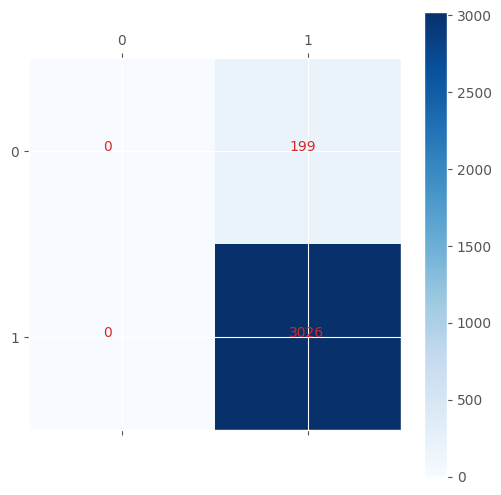

In [151]:
#Visualization for our XGBoost model confusion matrix 
plot_confusion_matrix(y_test3, prediction_xgb3)

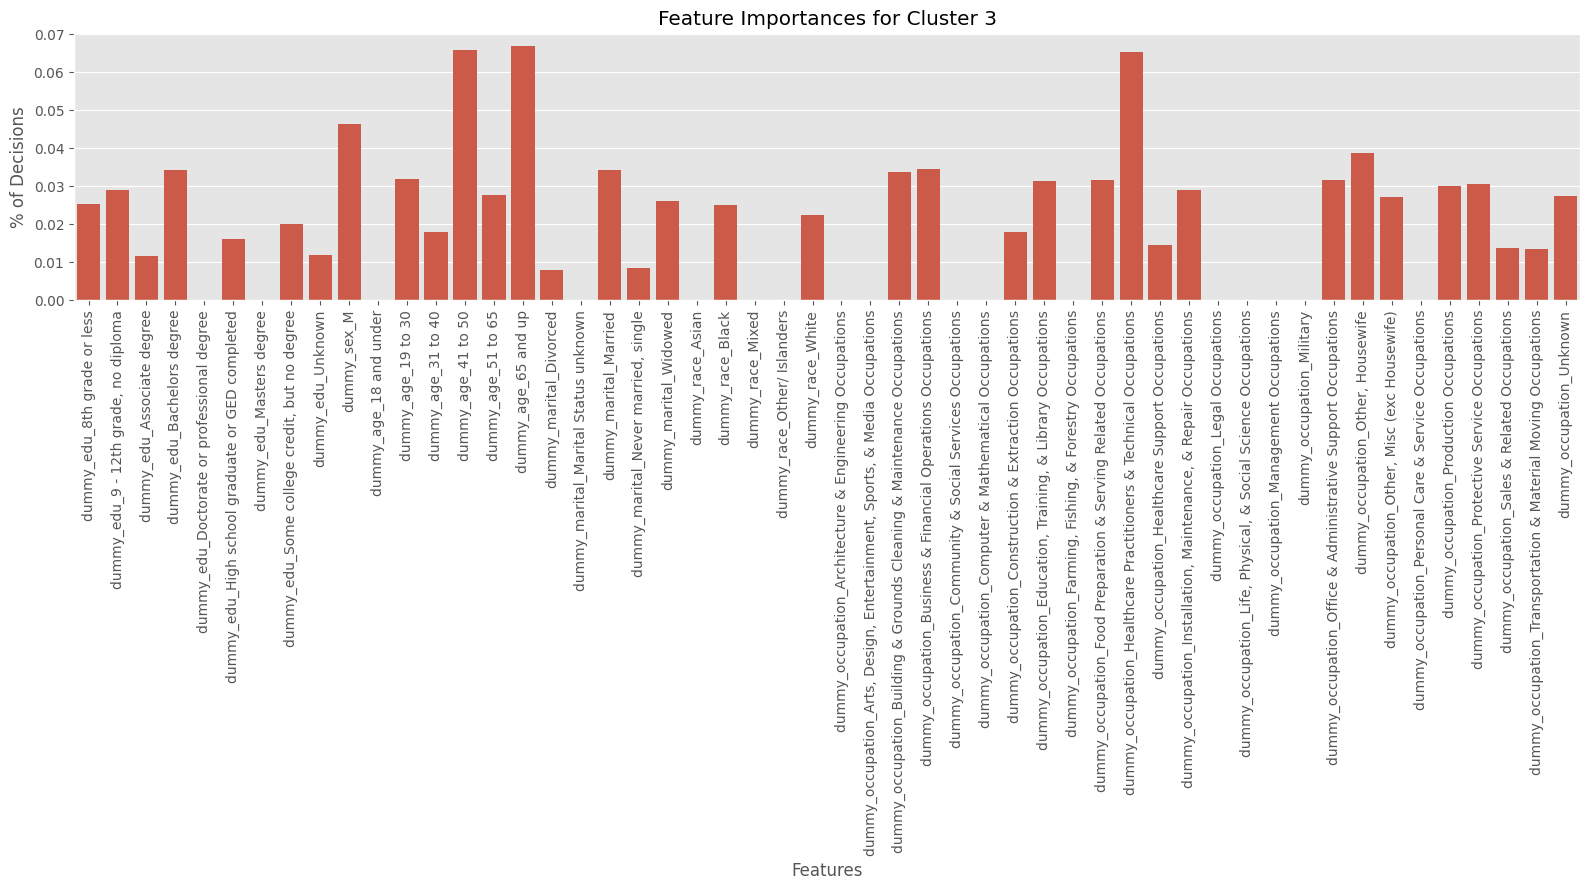

In [152]:
clus3_features = xgb3.feature_importances_

feature_importance(x_train3, clus3_features, 3)

In [ ]:
clus3_feature_importances_table = pd.DataFrame(data = {"Features": x_train3.columns, "Data": clus3_features})
clus3_feature_importances_table[clus3_feature_importances_table["Data"] > 0]

,Features,Data
0,dummy_edu_8th grade or less,0.025410
1,"dummy_edu_9 - 12th grade, no diploma",0.029096
2,dummy_edu_Associate degree,0.011510
3,dummy_edu_Bachelors degree,0.034290
5,dummy_edu_High school graduate or GED completed,0.016157
7,"dummy_edu_Some college credit, but no degree",0.019962
8,dummy_edu_Unknown,0.011944
9,dummy_sex_M,0.046308
11,dummy_age_19 to 30,0.031858
12,dummy_age_31 to 40,0.018016


# Cluster 4: XGBoost/ No oversample/ Tuned

In [83]:
cluster_4 = cluster_4.drop('Clusters', axis=1)
cluster_4.head()

,Education,Sex,AgeCategory,Marital Status,Race,Occupation,Death
0,High school graduate or GED completed,M,19 to 30,"Never married, single",Other/ Islanders,"Farming, Fishing, & Forestry Occupations",Accidental Drug Poisoning
1,High school graduate or GED completed,M,19 to 30,"Never married, single",White,"Farming, Fishing, & Forestry Occupations",Accidental Drug Poisoning
2,Bachelors degree,M,19 to 30,"Never married, single",Black,Business & Financial Operations Occupations,Accidental Drug Poisoning
3,"Some college credit, but no degree",M,19 to 30,"Never married, single",White,Healthcare Practitioners & Technical Occupations,Accidental Drug Poisoning
4,"9 - 12th grade, no diploma",M,19 to 30,"Never married, single",Other/ Islanders,"Other, Misc (exc Housewife)",Accidental Drug Poisoning


In [84]:
cluster_4 = pd.get_dummies(cluster_4, columns=['Education', 'Sex', 'AgeCategory', 'Marital Status', 'Race', 'Occupation', 'Death'], prefix=['dummy_edu','dummy_sex','dummy_age', 'dummy_marital', 'dummy_race', 'dummy_occupation', 'dummy_death'])
cluster_4.head()

,dummy_edu_8th grade or less,"dummy_edu_9 - 12th grade, no diploma",dummy_edu_Associate degree,dummy_edu_Bachelors degree,dummy_edu_Doctorate or professional degree,dummy_edu_High school graduate or GED completed,dummy_edu_Masters degree,"dummy_edu_Some college credit, but no degree",dummy_edu_Unknown,dummy_sex_F,...,"dummy_occupation_Other, Housewife","dummy_occupation_Other, Misc (exc Housewife)",dummy_occupation_Personal Care & Service Occupations,dummy_occupation_Production Occupations,dummy_occupation_Protective Service Occupations,dummy_occupation_Sales & Related Occupations,dummy_occupation_Transportation & Material Moving Occupations,dummy_occupation_Unknown,dummy_death_Accidental Drug Poisoning,dummy_death_Other
0,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
1,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
2,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
3,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,1,0
4,0,1,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,1,0


In [85]:
# Death and Sex attribute has two values only so we can drop one of them since they are considered redundant. 
#We are predicting Accidental or not, so only 1 column is sufficient. 

cluster_4.drop('dummy_death_Other', axis=1, inplace=True)
cluster_4.rename(columns={'dummy_death_Accidental Drug Poisoning': 'Death'}, inplace=True)
cluster_4.drop('dummy_sex_F', axis=1, inplace=True)

#1 = Accidental, 0 = Other

In [86]:
clus4_train, clus4_test = train_test_split(cluster_4, test_size=0.25, random_state=34)
print(clus4_train.shape)
print(clus4_test.shape)

(11271, 52)
(3758, 52)


In [87]:
print(clus4_train["Death"].count())
print(clus4_train["Death"].value_counts(normalize = True))
clus4_train["Death"].value_counts()

11271
1    0.948097
0    0.051903
Name: Death, dtype: float64


1    10686
0      585
Name: Death, dtype: int64

In [88]:
x_train4 = clus4_train.drop('Death', axis=1)
y_train4 = clus4_train['Death']

In [89]:
x_test4 = clus4_test.drop('Death', axis=1)
y_test4 = clus4_test['Death']

In [90]:
print(f'Our baseline model for Cluster 4 is {y_train4.value_counts(normalize = True)[0] * 100}% accurate')
print(f'Our baseline model for Cluster 4 based on the testing partition is {y_test4.value_counts(normalize = True)[0] * 100}% accurate')

Our baseline model for Cluster 4 is 5.190311418685121% accurate
Our baseline model for Cluster 4 based on the testing partition is 5.401809473124002% accurate


In [91]:
#Using CrossValidation for model selection: 
clus4_models_dict = {'RandomForest': RandomForestClassifier(n_estimators = 10, criterion='gini', random_state = 34), 
                     'NaiveBayes': MultinomialNB(alpha=1.0, fit_prior=True), 
                     'XGBoost': XGBClassifier(n_estimators=2, max_depth=2, learning_rate=1, objective='binary:logistic'),
                     'Decision Tree': DecisionTreeClassifier(criterion="entropy",max_leaf_nodes=5, random_state = 34)}

clus4_model_cv_score = {}

for name, model in clus4_models_dict.items():
    score4 = cross_val_score(model, x_train4, y_train4, cv=kfold)
    clus4_model_cv_score[name] = score4.mean()

print(f'Model Scores: {clus4_model_cv_score}')

Model Scores: {'RandomForest': 0.9460554758443619, 'NaiveBayes': 0.9480960561838057, 'XGBoost': 0.9480960561838057, 'Decision Tree': 0.9480960561838057}


In [92]:
#We are going to use XGBoost or DecisionTree as they have the highest accuracies (using stratified k fold cv)
clus4_params = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'gamma': [0, 0.1, 0.2],
    'min_child_weight': [3, 5, 7],
    'scale_pos_weight': [15, 18, 20]
}

grid4 = GridSearchCV(XGBClassifier(), param_grid = clus4_params, cv = kfold, n_jobs = -1, verbose = 1)
grid4.fit(x_train4, y_train4)

print("Best Parameters found for Cluster 4: ", grid4.best_params_)
print("Best Accuracy through grid search for Cluster 4: %.3f"%grid4.best_score_)

Fitting 10 folds for each of 8748 candidates, totalling 87480 fits
Best Parameters found for Cluster 4:  {'colsample_bytree': 0.7, 'gamma': 0, 'learning_rate': 0.01, 'max_depth': 3, 'min_child_weight': 3, 'n_estimators': 100, 'scale_pos_weight': 15, 'subsample': 0.7}
Best Accuracy through grid search for Cluster 4: 0.948


In [154]:
#BEST SCORE:
xgb4 = XGBClassifier(colsample_bytree = 0.7, gamma = 0, learning_rate = 0.01, max_depth = 3,
                    min_child_weight = 3, n_estimators = 100, scale_pos_weight = 15, subsample = 0.7, random_state = 34).fit(x_train4, y_train4)

xgb4_score = cross_val_score(xgb4, x_train4, y_train4, cv=kfold)

In [155]:
print(f"Our XGBoost with the best optimized parameters on the Testing set for Cluster 4 is: {xgb4.score(x_test4, y_test4) * 100}% accurate")
print(f"Our XGBoost Classification model with optimized parameters with k-fold cross validation on the training dataset for Cluster 4 is: {xgb4_score.mean() * 100}% accurate")

Our XGBoost with the best optimized parameters on the Testing set for Cluster 4 is: 94.598190526876% accurate
Our XGBoost Classification model with optimized parameters with k-fold cross validation on the training dataset for Cluster 4 is: 94.80960561838057% accurate


In [156]:
prediction_xgb4 = xgb4.predict(x_test4)

print("Classification Report for Cluster 4:")
print(classification_report(y_test4, prediction_xgb4))
print("===========")
print("Confusion Matrix")
print(confusion_matrix(y_test4, prediction_xgb4))
print("============")
print("Accuracy Score: ", accuracy_score(prediction_xgb4, y_test4))
print("==============")

test4_predictions_proba = xgb4.predict_proba(x_test4)
log_4 = log_loss(y_test4, test4_predictions_proba)
print("Log Loss: {:.4}".format(log_4))
print("===============")

Classification Report for Cluster 4:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       203
           1       0.95      1.00      0.97      3555

    accuracy                           0.95      3758
   macro avg       0.47      0.50      0.49      3758
weighted avg       0.89      0.95      0.92      3758

Confusion Matrix
[[   0  203]
 [   0 3555]]
Accuracy Score:  0.94598190526876
Log Loss: 0.2108


/home/aryan/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/aryan/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/aryan/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


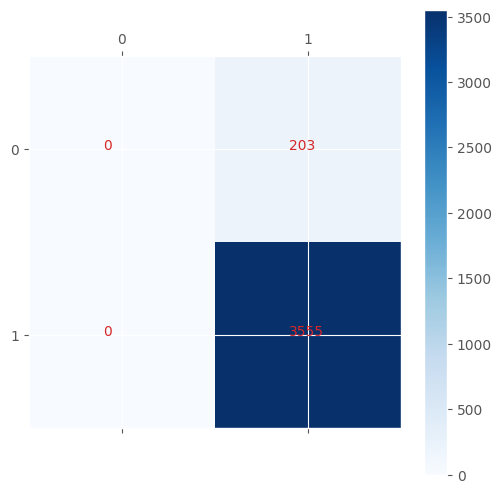

In [157]:
#Visualization for our XGBoost model confusion matrix 
plot_confusion_matrix(y_test4, prediction_xgb4)

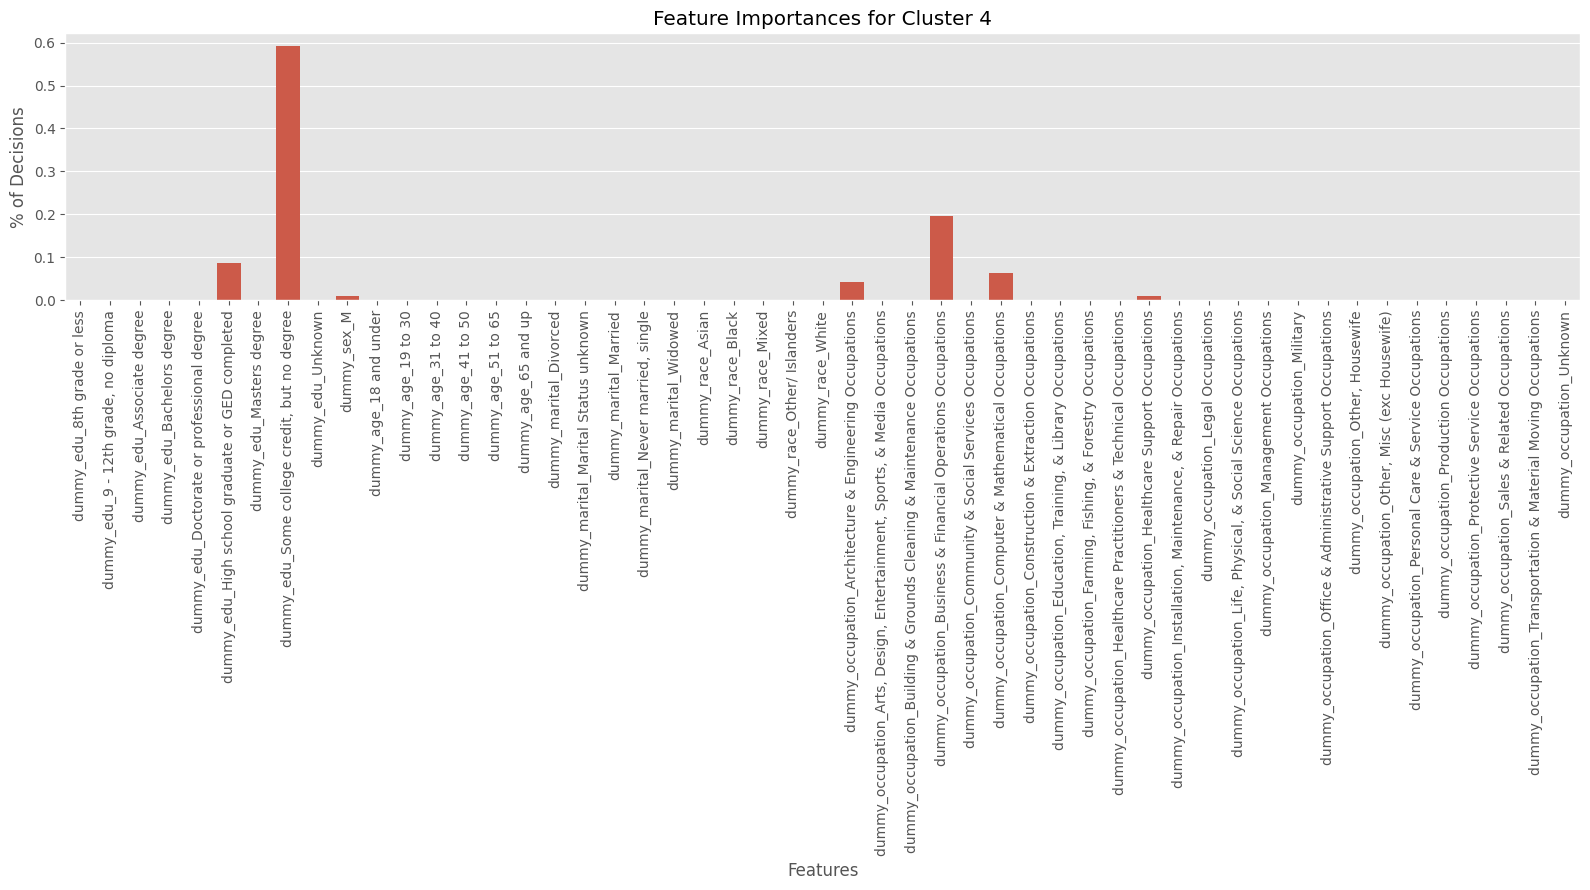

In [158]:
clus4_features = xgb4.feature_importances_

feature_importance(x_train4, clus4_features, 4)

In [ ]:
clus4_feature_importances_table = pd.DataFrame(data = {"Features": x_train4.columns, "Data": clus4_features})
clus4_feature_importances_table[clus4_feature_importances_table["Data"] > 0]

,Features,Data
5,dummy_edu_High school graduate or GED completed,0.087044
7,"dummy_edu_Some college credit, but no degree",0.591980
9,dummy_sex_M,0.009232
26,dummy_occupation_Architecture & Engineering Oc...,0.042643
29,dummy_occupation_Business & Financial Operatio...,0.195905
31,dummy_occupation_Computer & Mathematical Occup...,0.063964
36,dummy_occupation_Healthcare Support Occupations,0.009232
